**34367** *Intelligent Systems Project*, Technical University of Denmark

---

# Clinical Operations Management Project

**Content:**
- Part 1: Building a basic `Control Terminal Dashboard`
- Part 2: Regression on the `body` dataset with regularizaton
- Part 3: Classifying the `wine` dataset with regularizaton
- Part 4: Ensemble methods

# Basic Control Terminal Dashboard

## Basic Control Terminal Dashboard - Capacity Planning

During the initial interview round what resonated the most with the hospital directors and decision makers was having the available information each day to see how the hospital is working. The most important metric for them across all of the conversations I had was **Installed capacity vs Used capacity**. This dashboard gives a basic understandment of how this metric works for each department in the hospital. 

In [2]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns


c:\Users\mauri\miniforge3\envs\dtu02452\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Loading the dataset
df_services_weekly = pd.read_csv('data/services_weekly.csv')
df_patients = pd.read_csv('data/patients.csv')
df_staff_schedule = pd.read_csv('data/staff_schedule.csv')
df_staff = pd.read_csv('data/staff.csv')

In [4]:
#Converting dates to datetime objects
df_patients['arrival_date'] = pd.to_datetime(df_patients['arrival_date'])
df_patients['departure_date'] = pd.to_datetime(df_patients['departure_date'])

# Create a range of weeks based on your dataset's timeline
# We'll find the start and end of the entire dataset
start_date = df_patients['arrival_date'].min().to_period('W').start_time
end_date = df_patients['departure_date'].max().to_period('W').end_time
weeks = pd.date_range(start=start_date, end=end_date, freq='W-MON')

# Process Census: Count patients present during each week
weekly_census_list = []

for week_start in weeks:
    week_end = week_start + pd.Timedelta(days=6)
    
    # A patient is present if:
    # They arrived before the week ended AND they left after the week started
    active_patients = df_patients[
        (df_patients['arrival_date'] <= week_end) & 
        (df_patients['departure_date'] >= week_start)
    ]
    
    # Group by service to see where they are
    counts = active_patients.groupby('service').size().reset_index(name='used_capacity')
    counts['week_start'] = week_start
    # Optional: Map back to the 'week' integer used in your other CSVs
    # (Assuming Week 1 is the first week of the dataset)
    counts['week_number'] = ((week_start - start_date).days // 7) + 1
    
    weekly_census_list.append(counts)

# Final Result: Used Capacity per Service per Week
df_used_capacity = pd.concat(weekly_census_list, ignore_index=True)

In [5]:
# Merge the census data with the installed capacity data
# We match on 'week' (or week_number) and 'service'
final_capacity_df = pd.merge(
    df_services_weekly[['week', 'service', 'available_beds','staff_morale','patient_satisfaction']], 
    df_used_capacity[['week_number', 'service', 'used_capacity']],
    left_on=['week', 'service'],
    right_on=['week_number', 'service'],
    how='left'
)

# Calculate Utilization Rate
final_capacity_df['utilization_pct'] = (final_capacity_df['used_capacity'] / final_capacity_df['available_beds']) * 100

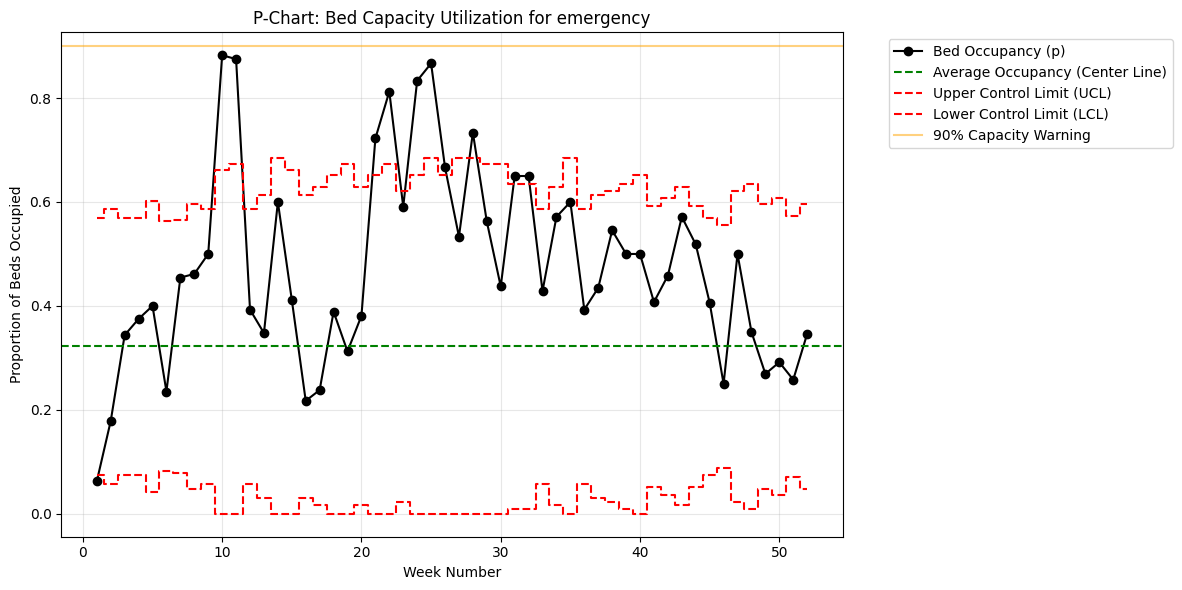

In [6]:
# P-Chart 
# p = proportion of beds used
final_capacity_df['p'] = final_capacity_df['used_capacity'] / final_capacity_df['available_beds']

# p_bar = average proportion across the whole dataset
p_bar = final_capacity_df['used_capacity'].sum() / final_capacity_df['available_beds'].sum()

# Variable Control Limits because n (available_beds) can vary weekly
final_capacity_df['sigma'] = np.sqrt((p_bar * (1 - p_bar)) / final_capacity_df['available_beds'])
final_capacity_df['UCL'] = p_bar + (3 * final_capacity_df['sigma'])
final_capacity_df['LCL'] = p_bar - (3 * final_capacity_df['sigma'])
final_capacity_df['LCL'] = final_capacity_df['LCL'].clip(lower=0) # Cannot have negative occupancy

# 5. Visualization
plt.figure(figsize=(12, 6))
service_to_plot = final_capacity_df['service'].unique()[0] # Pick one service for the chart
subset = final_capacity_df[final_capacity_df['service'] == service_to_plot].sort_values('week')

plt.plot(subset['week'], subset['p'], marker='o', linestyle='-', color='black', label='Bed Occupancy (p)')
plt.axhline(p_bar, color='green', linestyle='--', label='Average Occupancy (Center Line)')
plt.step(subset['week'], subset['UCL'], color='red', linestyle='--', where='mid', label='Upper Control Limit (UCL)')
plt.step(subset['week'], subset['LCL'], color='red', linestyle='--', where='mid', label='Lower Control Limit (LCL)')

# Manager's "Hard Limit" (e.g., 90% target)
plt.axhline(0.90, color='orange', linestyle='-', alpha=0.5, label='90% Capacity Warning')

plt.title(f'P-Chart: Bed Capacity Utilization for {service_to_plot}')
plt.xlabel('Week Number')
plt.ylabel('Proportion of Beds Occupied')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:


def get_hospital_snapshot(target_week, service_name, final_capacity_df):
    # 1. Calculate the range (Target week and 2 weeks prior)
    week_range = [target_week - 2, target_week - 1, target_week]
    
    # 2. Filter data for the specific service and the 3-week window
    snapshot = final_capacity_df[
        (final_capacity_df['service'] == service_name) & 
        (final_capacity_df['week'].isin(week_range))
    ].sort_values('week')
    
    if snapshot.empty:
        return f"No data found for week {target_week} in {service_name}."

    # 3. Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plotting the 3-week trend
    ax.plot(snapshot['week'], snapshot['p'], marker='o', color='black', linewidth=2, label='Occupancy')
    ax.step(snapshot['week'], snapshot['UCL'], color='red', linestyle='--', label='Upper Control Limit')
    ax.axhline(p_bar, color='green', linestyle=':', label='System Average')
    
    # Highlighting the "Current" week
    current_week_data = snapshot[snapshot['week'] == target_week]
    ax.scatter(current_week_data['week'], current_week_data['p'], color='red', s=100, zorder=5, label='Target Week')

    ax.set_ylim(0, 1.1)
    ax.set_xticks(week_range)
    ax.set_title(f"Operational Snapshot: {service_name} | Week {target_week} Context")
    ax.set_ylabel("Occupancy Proportion")
    ax.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    # 4. "The Intelligent Briefing" - Decision Support Output
    print(f"--- MANAGER BRIEFING: WEEK {target_week} ---")
    
    # Calculate Trend
    if len(snapshot) > 1:
        start_p = snapshot.iloc[0]['p']
        end_p = snapshot.iloc[-1]['p']
        diff = end_p - start_p
        trend = "INCREASING" if diff > 0 else "DECREASING"
        print(f"TREND: The occupancy is {trend} by {abs(diff):.1%} over the last 3 weeks.")
    
    # Check for Criticality
    current_p = current_week_data['p'].values[0]
    ucl = current_week_data['UCL'].values[0]
    
    if current_p > ucl:
        print("STATUS: CRITICAL. You are currently exceeding your statistical safety limit.")
    elif current_p > 0.85:
        print("STATUS: CAUTION. High occupancy may begin impacting staff morale.")
    else:
        print("STATUS: STABLE. Operating within normal capacity parameters.")

#Example: get_hospital_snapshot(target_week=10, service_name='ICU', final_capacity_df=final_capacity_df)


In [8]:
# 2. Define the week you want to analyze
target_week = 43  

   HOSPITAL COMMAND CENTER: WEEK 43 REPORT


>>> ANALYZING SERVICE: EMERGENCY <<<


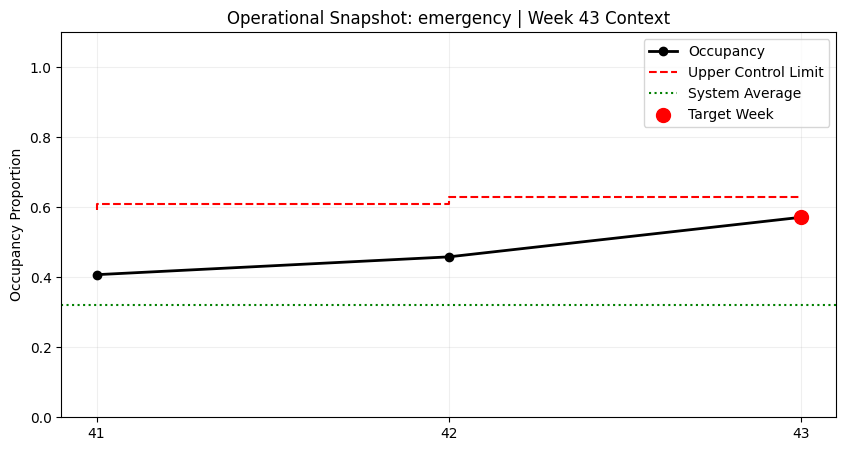

--- MANAGER BRIEFING: WEEK 43 ---
TREND: The occupancy is INCREASING by 16.4% over the last 3 weeks.
STATUS: STABLE. Operating within normal capacity parameters.
--------------------------------------------------

>>> ANALYZING SERVICE: SURGERY <<<


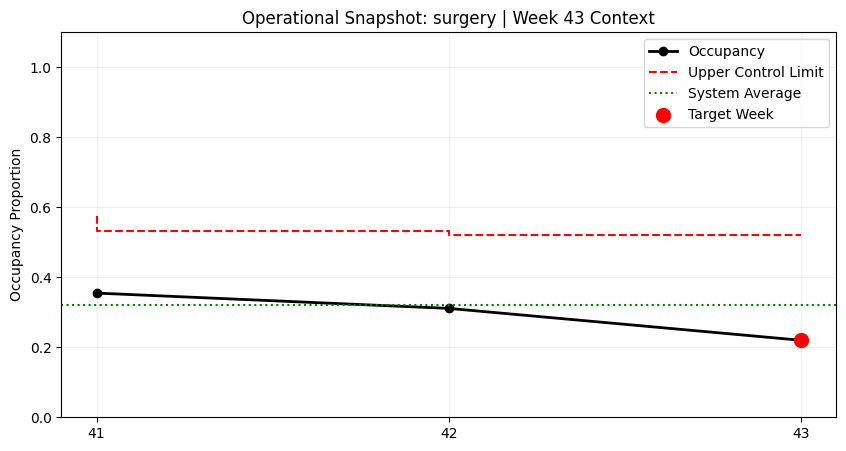

--- MANAGER BRIEFING: WEEK 43 ---
TREND: The occupancy is DECREASING by 13.5% over the last 3 weeks.
STATUS: STABLE. Operating within normal capacity parameters.
--------------------------------------------------

>>> ANALYZING SERVICE: GENERAL_MEDICINE <<<


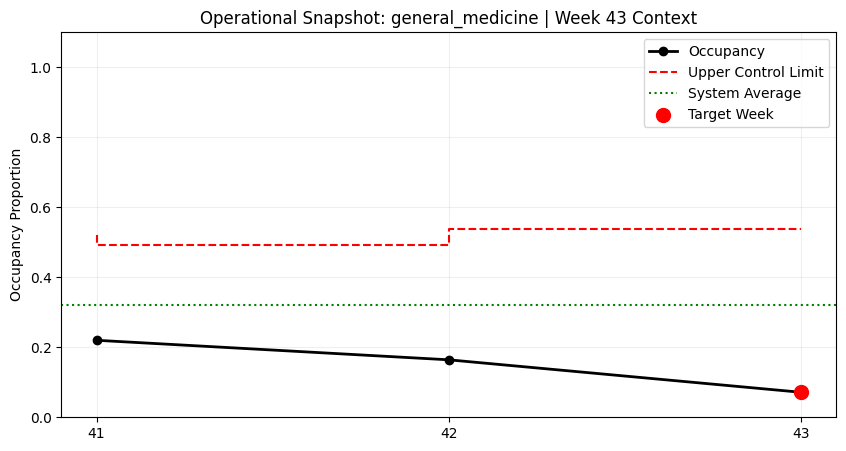

--- MANAGER BRIEFING: WEEK 43 ---
TREND: The occupancy is DECREASING by 14.9% over the last 3 weeks.
STATUS: STABLE. Operating within normal capacity parameters.
--------------------------------------------------

>>> ANALYZING SERVICE: ICU <<<


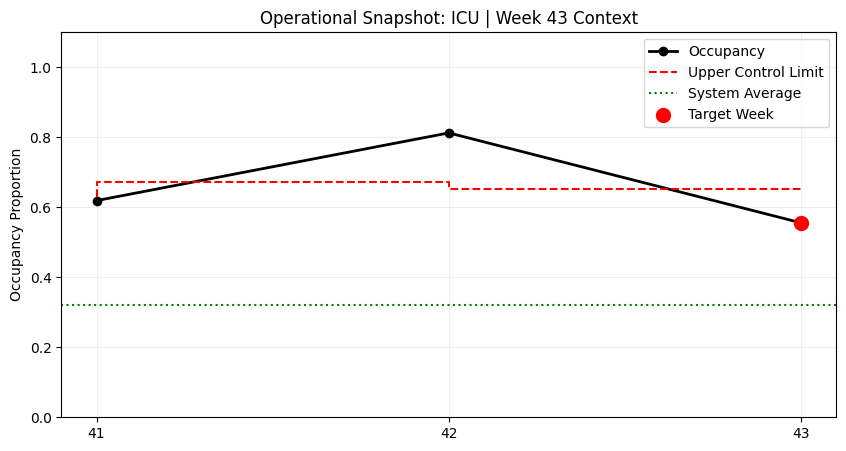

--- MANAGER BRIEFING: WEEK 43 ---
TREND: The occupancy is DECREASING by 6.3% over the last 3 weeks.
STATUS: STABLE. Operating within normal capacity parameters.
--------------------------------------------------


In [9]:
#Seeing all snapshot for week 10 across all services:
    
# 1. Get the list of all unique services
all_services = final_capacity_df['service'].unique()


print(f"==================================================")
print(f"   HOSPITAL COMMAND CENTER: WEEK {target_week} REPORT")
print(f"==================================================\n")

# 3. Loop through every service and run the analysis
for service in all_services:
    print(f"\n>>> ANALYZING SERVICE: {service.upper()} <<<")
    
    # This calls the function we built in the previous step
    get_hospital_snapshot(target_week=target_week, service_name=service, final_capacity_df=final_capacity_df)
    
    print("-" * 50) # Visual separator for the terminal output

## Basic Control Terminal Dashboard - Staff Mapping

Something that was emphizised as well during the initial interviews was that knowing the load the staff was under needed Staff to patient ratios. Capacity tells you how much of the installations are being tested, and **Staff to patient ratios** tell you how much the staff is being worked each week. 


In [10]:
# 1. Filter for present staff directly from schedule
present_staff = df_staff_schedule[df_staff_schedule['present'] == 1].copy()

# 2. Standardize role names to lowercase to prevent case-sensitivity errors
present_staff['role'] = present_staff['role'].astype(str).str.lower().str.strip()

# 3. Pivot the roles into columns
# This counts how many of each role are in each service for each week
staff_counts = present_staff.groupby(['week', 'service', 'role']).size().unstack(fill_value=0).reset_index()

# 4. Standardize column names for our math
# Check your specific CSV, but this usually maps 'nurse' and 'doctor' roles
staff_counts = staff_counts.rename(columns={
    'doctor': 'docs_present',
    'nurse': 'nurses_present'
})

# 5. Ensure the columns exist (even if 0 for a specific week)
if 'docs_present' not in staff_counts.columns: staff_counts['docs_present'] = 0
if 'nurses_present' not in staff_counts.columns: staff_counts['nurses_present'] = 0

# 6. Merge with your capacity data (final_capacity_df)
df_ratios = pd.merge(final_capacity_df, staff_counts, on=['week', 'service'], how='left').fillna(0)

# 7. Calculate Ratios
df_ratios['nurse_to_patient'] = df_ratios['used_capacity'] / df_ratios['nurses_present'].replace(0, np.nan)
df_ratios['doc_to_patient'] = df_ratios['used_capacity'] / df_ratios['docs_present'].replace(0, np.nan)

# Fill NaNs back to 0 for display
df_ratios[['nurse_to_patient', 'doc_to_patient']] = df_ratios[['nurse_to_patient', 'doc_to_patient']].fillna(0)

In [11]:
present_staff.head()

,week,staff_id,staff_name,role,service,present
0,1,STF-b77cdc60,Allison Hill,doctor,emergency,1
1,2,STF-b77cdc60,Allison Hill,doctor,emergency,1
3,4,STF-b77cdc60,Allison Hill,doctor,emergency,1
4,5,STF-b77cdc60,Allison Hill,doctor,emergency,1
6,7,STF-b77cdc60,Allison Hill,doctor,emergency,1


In [12]:

week_data = df_ratios[df_ratios['week'] == target_week]

print(f"{'='*95}")
print(f" STAFFING & CAPACITY REPORT - WEEK {target_week}")
print(f"{'='*95}")
# Updated Header to include Doctors
print(f"{'Service':<18} | {'Census':<6} | {'Nurses':<6} | {'N:P Ratio':<9} | {'Docs':<5} | {'D:P Ratio':<9} | {'Status'}")
print(f"{'-'*95}")

for _, row in week_data.iterrows():
    # Format the ratios for display
    n_ratio = f"1:{row['nurse_to_patient']:.1f}" if row['nurses_present'] > 0 else "N/A"
    d_ratio = f"1:{row['doc_to_patient']:.1f}" if row['docs_present'] > 0 else "N/A"
    
    # Intelligence Logic: Combined Status
    # We flag CRITICAL if EITHER nurses are overwhelmed (>6) or docs are overwhelmed (>15)
    if row['nurse_to_patient'] > 6 or row['doc_to_patient'] > 15:
        status = "CRITICAL"
    elif row['nurse_to_patient'] > 4.5 or row['doc_to_patient'] > 12:
        status = "STRESSED"
    elif row['used_capacity'] == 0:
        status = "EMPTY"
    else:
        status = "SAFE"
    
    # Printing the formatted row
    print(f"{row['service']:<18} | {int(row['used_capacity']):<6} | "
          f"{int(row['nurses_present']):<6} | {n_ratio:<9} | "
          f"{int(row['docs_present']):<5} | {d_ratio:<9} | {status}")

# Final Summary Insights
avg_n_ratio = week_data['nurse_to_patient'].mean()
avg_d_ratio = week_data['doc_to_patient'].mean()

print(f"{'-'*95}")
print(f"Hospital-Wide Averages -> Nursing Load: 1:{avg_n_ratio:.1f} | Doctor Load: 1:{avg_d_ratio:.1f}")
print(f"{'='*95}")

 STAFFING & CAPACITY REPORT - WEEK 43
Service            | Census | Nurses | N:P Ratio | Docs  | D:P Ratio | Status
-----------------------------------------------------------------------------------------------
emergency          | 12     | 19     | 1:0.6     | 8     | 1:1.5     | SAFE
surgery            | 11     | 11     | 1:1.0     | 3     | 1:3.7     | SAFE
general_medicine   | 3      | 15     | 1:0.2     | 4     | 1:0.8     | SAFE
ICU                | 10     | 18     | 1:0.6     | 6     | 1:1.7     | SAFE
-----------------------------------------------------------------------------------------------
Hospital-Wide Averages -> Nursing Load: 1:0.6 | Doctor Load: 1:1.9


## Basic Control Terminal Dashboard - Acuity Risk

Something that can also give us a good understandment of the clinical load the hospital and its staff is under is the mean Acuity. This indicator gives us the intensity of medical care required for a patient. Since the dataset we are using doesnt have a *severity* column, Age will be used as an **estimator for the intensity of medical care required**, stemming from the fact that in average, older patients with chronic conditions represent higher clincal workloads. 


We will make synthetic data for the severity level based on the age of the individual based on the logic explained earlier. Thresholding will be done in a U shape in order to account for very young and older patients having a higher average severity score. 

In [13]:
def calculate_severity(age):
    if age <= 3 or age >= 90:
        return 10
    elif 5 <= age < 15:
        return 1
    elif 15 <= age < 20:
        return 2
    elif 20 <= age < 30:
        return 3
    elif 30 <= age < 40:
        return 4
    elif 40 <= age < 50:
        return 5
    elif 50 <= age < 60:
        return 6
    elif 60 <= age < 70:
        return 7
    elif 70 <= age < 80:
        return 8
    elif 80 <= age < 90:
        return 9
    else:
        return 5 # Default for gaps like age 4

# Apply this to your patient dataframe before aggregating
df_patients['severity_score'] = df_patients['age'].apply(calculate_severity)

In [14]:
# Process Census and Age: Extract metrics for patients present during each week
weekly_metrics_list = []

for week_start in weeks:
    week_end = week_start + pd.Timedelta(days=6)
    
    # Identify patients physically in a bed during this specific 7-day window
    active_patients = df_patients[
        (df_patients['arrival_date'] <= week_end) & 
        (df_patients['departure_date'] >= week_start)
    ].copy()
    
    if not active_patients.empty:
        # Group by service to calculate Census AND Mean Age
        stats = active_patients.groupby('service').agg(
            used_capacity=('patient_id', 'count'),
            avg_age_acuity=('age', 'mean'),
            avg_severity=('severity_score', 'mean')
        ).reset_index()
        
        stats['week_start'] = week_start
        stats['week'] = ((week_start - start_date).days // 7) + 1
        
        weekly_metrics_list.append(stats)

# Combine into a single dataframe
df_weekly_acuity = pd.concat(weekly_metrics_list, ignore_index=True)

# Merge this into your existing df_ratios master table
# We replace the old used_capacity and add the new avg_age_acuity
df_ratios = pd.merge(
    df_ratios.drop(columns=['used_capacity'], errors='ignore'), # Drop old count to avoid duplicates
    df_weekly_acuity, 
    on=['week', 'service'], 
    how='left'
).fillna(0)

In [15]:
df_ratios.head()

,week,service,available_beds,staff_morale,patient_satisfaction,week_number,utilization_pct,p,sigma,UCL,LCL,docs_present,nurses_present,nursing_assistant,nurse_to_patient,doc_to_patient,used_capacity,avg_age_acuity,avg_severity,week_start
0,1,emergency,32,70,67,1,6.250000,0.062500,0.082603,0.569895,0.074275,8.0,18.0,9.0,0.111111,0.250000,2,15.5,2.000000,2024-12-30
1,1,surgery,45,78,83,1,4.444444,0.044444,0.069657,0.531057,0.113113,3.0,15.0,5.0,0.133333,0.666667,2,50.0,5.500000,2024-12-30
2,1,general_medicine,37,43,97,1,5.405405,0.054054,0.076820,0.552544,0.091626,5.0,15.0,7.0,0.133333,0.400000,2,38.0,4.000000,2024-12-30
3,1,ICU,22,91,84,1,13.636364,0.136364,0.099623,0.620955,0.023215,6.0,17.0,8.0,0.176471,0.500000,3,41.0,4.666667,2024-12-30
4,2,emergency,28,64,75,2,17.857143,0.178571,0.088307,0.587005,0.057165,8.0,21.0,8.0,0.238095,0.625000,5,41.2,4.600000,2025-01-06


In [16]:
week_data = df_ratios[df_ratios['week'] == target_week]

print(f"{'='*110}")
print(f" CLINICAL ACUITY & STAFFING REPORT - WEEK {target_week}")
print(f"{'='*110}")
print(f"{'Service':<18} | {'Census':<6} | {'Avg Age':<8} | {'Severity':<8} | {'N:P Ratio':<9} | {'D:P Ratio':<9} | {'Status'}")
print(f"{'-'*110}")

for _, row in week_data.iterrows():
    n_ratio = f"1:{row['nurse_to_patient']:.1f}"
    d_ratio = f"1:{row['doc_to_patient']:.1f}"
    
    # Intelligence: Severity-Adjusted Risk
    # High Ratio + High Severity = RED ALERT
    if row['nurse_to_patient'] > 5 and row['avg_severity'] > 7:
        status = "CRITICAL"
    elif row['avg_severity'] > 8:
        status = "HIGH ACUITY"
    else:
        status = "STABLE"
    
   # Print formatted row
    print(f"{row['service']:<18} | {int(row['used_capacity']):<6} | "
          f"{row['avg_age_acuity']:<8.1f} | "
          f"{row['avg_severity']:<8.1f} | {n_ratio:<9} | "
          f"{d_ratio:<9} | {status}")

print(f"{'='*110}")

 CLINICAL ACUITY & STAFFING REPORT - WEEK 43
Service            | Census | Avg Age  | Severity | N:P Ratio | D:P Ratio | Status
--------------------------------------------------------------------------------------------------------------
emergency          | 12     | 50.0     | 6.2      | 1:0.6     | 1:1.5     | STABLE
surgery            | 11     | 51.4     | 5.6      | 1:1.0     | 1:3.7     | STABLE
general_medicine   | 3      | 52.3     | 6.0      | 1:0.2     | 1:0.8     | STABLE
ICU                | 10     | 44.1     | 4.9      | 1:0.6     | 1:1.7     | STABLE


## Basic Control Terminal Dashboard - Events counter

We are going to make a counter for how many specific events are present per service each week. This will be our last variable that we will be using in order to predict how much workload a specific ward offering a service is under each week and help a manager make decisions to avoid and adverse event. 

In [17]:
def count_events_by_week(df):
    """Count events grouped by week"""
    return pd.crosstab(df_services_weekly['week'], df_services_weekly['event'])

def count_specific_event_by_week_and_service(df, event_name):
    """Count a specific event showing week and service breakdown"""
    filtered = df_services_weekly[df_services_weekly['event'] == event_name]
    return pd.crosstab(filtered['week'], filtered['service'])

#event_service_week_count = count_specific_event_by_week_and_service(df_services_weekly, 'flu')
#event_service_week_count.head()
#event_count_week = count_events_by_week(df_services_weekly)
#event_count_week.head()

In [18]:
event_count_all = pd.crosstab(
    [df_services_weekly['week'], df_services_weekly['service']], 
    df_services_weekly['event']
).reset_index()

# Clean column names (strip spaces and lowercase for consistency)
event_count_all.columns = [str(c).strip().lower() for c in event_count_all.columns]

event_count_all.head()

,week,service,donation,flu,none,strike
0,1,ICU,0,1,0,0
1,1,emergency,0,0,1,0
2,1,general_medicine,0,1,0,0
3,1,surgery,0,1,0,0
4,2,ICU,1,0,0,0


In [19]:
def count_events_for_specific_week(df, week_number):
    """Count all events by service for a specific week"""
    filtered = df[df['week'] == week_number]
    if len(filtered) == 0:
        return f"No data found for week {week_number}"
    return pd.crosstab(filtered['service'], filtered['event'])

event_count_week = count_events_for_specific_week(df_services_weekly, target_week)
event_count_week.head()

event,donation,none
service,,
ICU,0,1
emergency,0,1
general_medicine,0,1
surgery,1,0


## Master Dataframe

In [20]:
master_df = final_capacity_df.copy()

# Merge Ratios (nurse_to_patient, doc_to_patient, avg_severity, avg_age)
# We assume 'service' and 'week' are the keys
master_df = pd.merge(master_df, df_ratios, on=['week', 'service'], how='left')

# Merge Event Counts (total_event_count or specific one-hot counts)
master_df = pd.merge(master_df,event_count_all, on=['week', 'service'], how='left')

# 4. Cleanup: Fill NaNs with 0 (for counts/ratios) 
# and ensure we have a 'safety_crisis' binary column
master_df = master_df.fillna(0)
master_df['safety_crisis'] = (master_df['p_x'] > master_df['UCL_x']).astype(int)
master_df['under_utilization'] = (master_df['p_x'] < master_df['LCL_y']).astype(int)

In [21]:
# 1. Define Total Capacity for each row
# This ensures we account for every physical bed in the service
master_df['total_beds'] = master_df['used_capacity_x'] + master_df['available_beds_x']

# 2. Group by Week to get Hospital-wide totals
hospital_totals = master_df.groupby('week').agg({
    'used_capacity_x': 'sum',
    'total_beds': 'sum'
}).reset_index()

# 3. Calculate Global Utilization %
hospital_totals['hospital_utilization_pct'] = ((
    hospital_totals['used_capacity_x'] / hospital_totals['total_beds'])*100
)

# 3. (Optional) Merge this back into your master_df if you want a 'hospital_avg' column
master_df = pd.merge(master_df, hospital_totals[['week', 'hospital_utilization_pct']], on='week', how='left')

hospital_totals.head()

,week,used_capacity_x,total_beds,hospital_utilization_pct
0,1,9,145,6.206897
1,2,27,154,17.532468
2,3,46,162,28.395062
3,4,48,199,24.120603
4,5,32,145,22.068966


In [22]:
master_df.head()

,week,service,available_beds_x,staff_morale_x,patient_satisfaction_x,week_number_x,used_capacity_x,utilization_pct_x,p_x,sigma_x,...,avg_severity,week_start,donation,flu,none,strike,safety_crisis,under_utilization,total_beds,hospital_utilization_pct
0,1,emergency,32,70,67,1,2,6.250000,0.062500,0.082603,...,2.000000,2024-12-30,0,0,1,0,0,1,34,6.206897
1,1,surgery,45,78,83,1,2,4.444444,0.044444,0.069657,...,5.500000,2024-12-30,0,1,0,0,0,1,47,6.206897
2,1,general_medicine,37,43,97,1,2,5.405405,0.054054,0.076820,...,4.000000,2024-12-30,0,1,0,0,0,1,39,6.206897
3,1,ICU,22,91,84,1,3,13.636364,0.136364,0.099623,...,4.666667,2024-12-30,0,1,0,0,0,0,25,6.206897
4,2,emergency,28,64,75,2,5,17.857143,0.178571,0.088307,...,4.600000,2025-01-06,0,0,1,0,0,0,33,17.532468


### Basic Control Terminal Dashboard 

In [23]:
# # 
# import streamlit as st
# import pandas as pd
# import plotly.graph_objects as go

# # --- ASSUMPTION: df_master contains week, service, used_capacity, etc. ---
# # Assuming 'p' is occupancy proportion and 'UCL' is the limit

# def run_capacity_dashboard(df):
#     st.sidebar.title("Navigation")
    
#     # 1. Dashboard Filters
#     target_week = st.sidebar.slider("Select Target Week", 
#                                     min_value=int(df['week'].min() + 2), # Start at +2 to allow 3-week window
#                                     max_value=int(df['week'].max()), 
#                                     value=10)
    
#     service_list = sorted(df['service'].unique().tolist())
#     selected_service = st.sidebar.selectbox("Select Service", service_list)

#     # 2. Logic: The 3-Week Snapshot
#     week_range = [target_week - 2, target_week - 1, target_week]
#     snapshot = df[(df['service'] == selected_service) & 
#                   (df['week'].isin(week_range))].sort_values('week')

#     if snapshot.empty:
#         st.error(f"No data found for Week {target_week} in {selected_service}")
#         return

#     current_data = snapshot[snapshot['week'] == target_week].iloc[0]

#     # 3. Visualization: The Statistical Process Control (SPC) Chart
#     st.subheader(f"📈 Operational Snapshot: {selected_service}")
    
#     fig = go.Figure()
    
#     # Occupancy Trend
#     fig.add_trace(go.Scatter(x=snapshot['week'], y=snapshot['p'], 
#                              mode='lines+markers', name='Occupancy',
#                              line=dict(color='black', width=3)))
    
#     # Upper Control Limit (UCL)
#     fig.add_trace(go.Scatter(x=snapshot['week'], y=snapshot['UCL'], 
#                              mode='lines', name='Safety Limit (UCL)',
#                              line=dict(color='red', dash='dash')))
    
#     # Target Week Highlight
#     fig.add_trace(go.Scatter(x=[target_week], y=[current_data['p']],
#                              mode='markers', name='Current Status',
#                              marker=dict(color='red', size=15)))

#     fig.update_layout(yaxis_range=[0, 1.1], title="Occupancy Trend vs. Safety Limits",
#                       xaxis_title="Week", yaxis_title="Occupancy %",
#                       legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1))

#     st.plotly_chart(fig, use_container_width=True)

#     # 4. The Intelligent Briefing (Decision Support)
#     st.markdown("---")
#     st.subheader("📋 Manager Briefing")
    
#     col1, col2 = st.columns(2)
    
#     # Trend Analysis
#     with col1:
#         if len(snapshot) > 1:
#             diff = snapshot.iloc[-1]['p'] - snapshot.iloc[0]['p']
#             trend_label = "INCREASING" if diff > 0 else "DECREASING"
#             color = "inverse" if diff > 0 else "normal" # Red for increasing occupancy
#             st.metric("3-Week Trend", f"{trend_label}", f"{diff:.1%}", delta_color=color)

#     # Status & Safety
#     with col2:
#         current_p = current_data['p']
#         ucl = current_data['UCL']
        
#         if current_p > ucl:
#             st.error(f"**STATUS: CRITICAL**\n\nExceeding Safety Limit ({ucl:.1%})")
#         elif current_p > 0.85:
#             st.warning(f"**STATUS: CAUTION**\n\nHigh occupancy detected ({current_p:.1%})")
#         else:
#             st.success(f"**STATUS: STABLE**\n\nOperating within normal parameters.")

# # Run the app
# run_capacity_dashboard(final_capacity_df)

In [24]:
# import streamlit as st
# import plotly.express as px

# # --- CONFIGURATION ---
# st.set_page_config(layout="wide", page_title="Hospital Command Center")

# # --- DATA LOADING (Assuming your df_master is ready) ---
# # df_master contains: week, service, used_capacity, nurses, docs, avg_severity, ev_flu, etc.

# # --- SIDEBAR FILTERS ---
# st.sidebar.header("Dashboard Filters")
# selected_week = st.sidebar.slider("Select Week", min_value=1, max_value=int(df_services_weekly['week'].max()), value=10)
# selected_service = st.sidebar.selectbox("Select Service", df_services_weekly['service'].unique())

# # Filter data based on selection
# week_data_services_weekly = df_services_weekly[df_services_weekly['week'] == selected_week]
# week_data_final_capacity = final_capacity_df[final_capacity_df['week'] == selected_week]
# week_data_ratios = df_ratios[df_ratios['week'] == selected_week] 
# week_data_event_count = count_events_for_specific_week(df_services_weekly, selected_week)
# #service_data = week_data[week_data['service'] == selected_service].iloc[0]

# # --- 1. KEY PERFORMANCE INDICATORS (KPIs) ---
# st.title(f"🏥 Hospital Command Center - Week {selected_week}")
# col1, col2, col3, col4, col5 = st.columns(5)

# col1.metric("Used vs Installed capacity", f"{int(week_data_final_capacity['used_capacity'].sum())} pts")
# col2.metric("Avg Severity", f"{week_data_ratios['avg_severity'].mean():.1f}/10")
# col3.metric("Nurse Ratio", f"1:{week_data_ratios['nurse_to_patient'].mean():.1f}")
# col4.metric("Doctor Ratio", f"1:{week_data_ratios['doc_to_patient'].mean():.1f}")
# col5.metric("Active Events", f"{int(week_data_event_count.sum())}")

# st.markdown("---")

# # --- 2. THE GRAPHS (Capacity & Staffing) ---
# left_col, right_col = st.columns(2)

# with left_col:
#     st.subheader("Hospital-Wide Capacity")
#     fig_cap = px.bar(week_data, x='service', y='used_capacity', color='avg_severity',
#                      title="Census by Service (Colored by Severity)")
#     st.plotly_chart(fig_cap, use_container_width=True)

# with right_col:
#     st.subheader("Staffing Load vs. Risk")
#     # A bubble chart showing Ratio vs Severity
#     fig_risk = px.scatter(week_data, x='nurse_to_patient', y='avg_severity', 
#                           size='used_capacity', hover_name='service',
#                           title="Staffing Stress vs. Clinical Risk")
#     st.plotly_chart(fig_risk, use_container_width=True)

# # --- 3. THE EVENT COUNTER (One-Hot Encoded Data) ---
# st.subheader(f"Detailed Event Analysis: {selected_service}")
# event_cols = [col for col in df_master.columns if col.startswith('ev_')]
# event_counts = service_data[event_cols].reset_index()
# event_counts.columns = ['Event Type', 'Count']
# event_counts['Event Type'] = event_counts['Event Type'].str.replace('ev_', '')

# # Display as a horizontal bar chart
# fig_events = px.bar(event_counts[event_counts['Count'] > 0], 
#                     x='Count', y='Event Type', orientation='h', 
#                     color='Count', color_continuous_scale='Blues')
# st.plotly_chart(fig_events, use_container_width=True)

# Next Steps

## Finding underlying data correlations

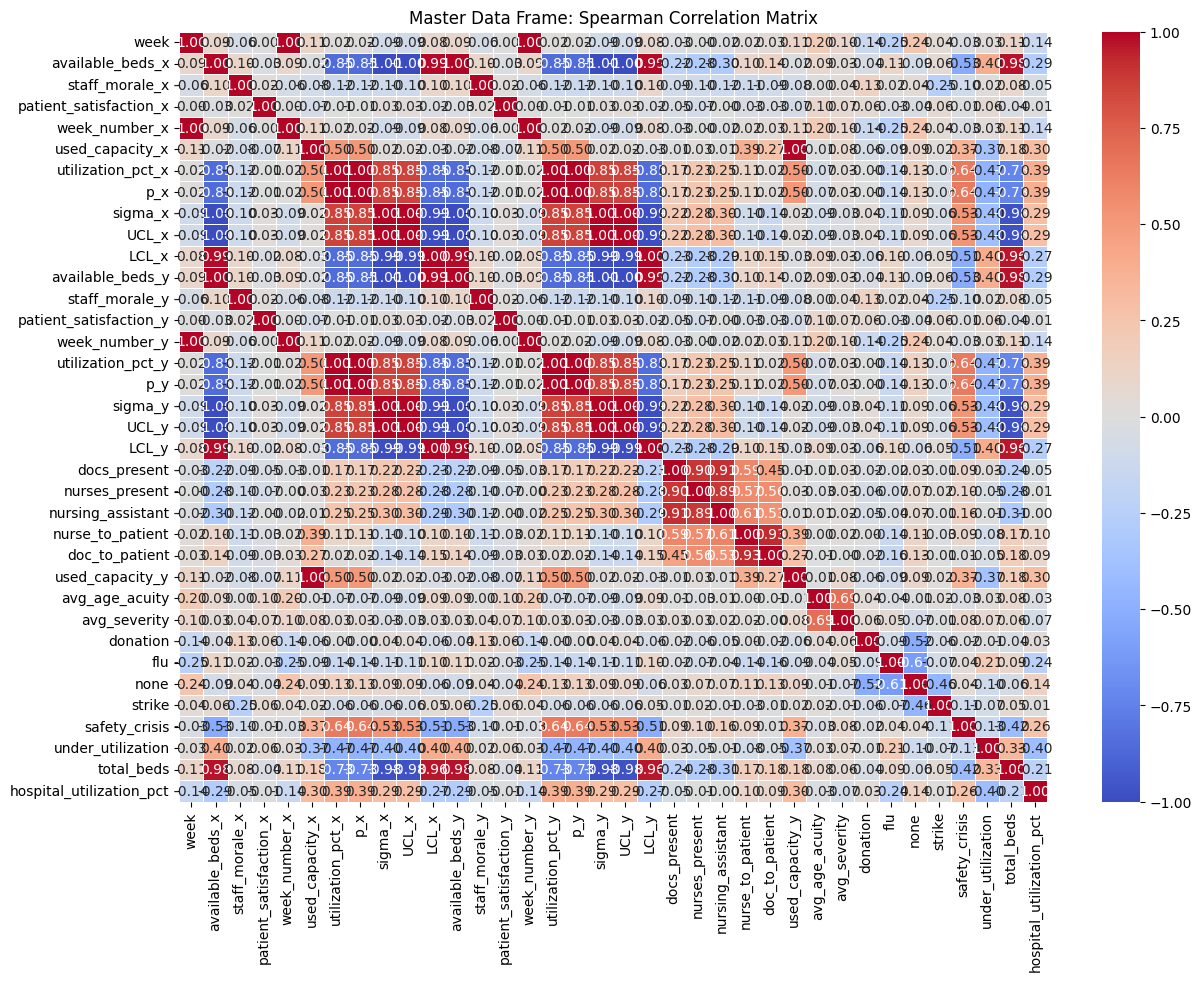

In [25]:

# Select only numeric columns (important to exclude 'service' or 'week' labels)
numeric_df = master_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
# We use 'spearman' because hospital data (like occupancy or severity) is often non-linear and ordinal.
corr_matrix = numeric_df.corr(method='spearman')

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title("Master Data Frame: Spearman Correlation Matrix")
plt.show()

Most of the correlations made by the heatmap seem to point to strong data correlation related to the feature transformations and calculations done in previous steps. There are only some datapoints that have a relative correlation between them that are not due to them being part of the calculation to get the number. For example *safety_crisis* event shows a strong correlation to the *utilization_pct*. All of this makes sense given that they are both dependent on the amount of occupied beds and installed capacity. 
Further non-linear correlation studies must be made to find data dependencies. 

In [26]:
from sklearn.feature_selection import mutual_info_regression

# Checking what specifically impacts 'patient_satisfaction_x'
X = numeric_df.drop(columns=['patient_satisfaction_x']).fillna(0)
y = numeric_df['patient_satisfaction_x'].fillna(0)

mi_scores = mutual_info_regression(X, y)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Mutual Information Scores for 'patient_satisfaction_x':")
print(mi_results)

Mutual Information Scores for 'patient_satisfaction_x':
patient_satisfaction_y      3.583534
avg_age_acuity              0.072447
available_beds_y            0.050003
available_beds_x            0.043991
total_beds                  0.032010
hospital_utilization_pct    0.022876
LCL_x                       0.019868
safety_crisis               0.019047
LCL_y                       0.018401
UCL_y                       0.010612
under_utilization           0.010476
none                        0.008033
UCL_x                       0.004138
sigma_y                     0.003868
week                        0.000000
staff_morale_x              0.000000
used_capacity_x             0.000000
sigma_x                     0.000000
week_number_x               0.000000
p_y                         0.000000
staff_morale_y              0.000000
week_number_y               0.000000
utilization_pct_y           0.000000
p_x                         0.000000
utilization_pct_x           0.000000
nursing_assistant  

In [27]:
# Checking what specifically impacts 'p_x' (bed occupancy)
X = numeric_df.drop(columns=['p_x']).fillna(0)
y = numeric_df['p_x'].fillna(0)

mi_scores = mutual_info_regression(X, y)
mi_results = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Mutual Information Scores for 'p_x' (bed occupancy):")
print(mi_results)

Mutual Information Scores for 'p_x' (bed occupancy):
utilization_pct_x           3.981579
p_y                         3.966784
utilization_pct_y           3.965141
UCL_y                       0.792613
UCL_x                       0.786769
sigma_x                     0.778965
sigma_y                     0.778121
available_beds_x            0.739548
available_beds_y            0.719613
LCL_x                       0.699375
LCL_y                       0.688907
total_beds                  0.420665
safety_crisis               0.418764
under_utilization           0.250923
used_capacity_y             0.244548
used_capacity_x             0.234240
doc_to_patient              0.166737
hospital_utilization_pct    0.135635
nurses_present              0.132941
nurse_to_patient            0.122185
nursing_assistant           0.103779
week_number_y               0.095178
week_number_x               0.092679
week                        0.083028
avg_severity                0.075586
flu                   

There is no clear variables that have a strong Mutual Information Score to predict patient satisfaction score nor bed ocupancy. The ones that have stronger correlations are a feature transformation for them. We will run dedicated libraries that find the interdependency of the system and recommend the flow of nodes. 

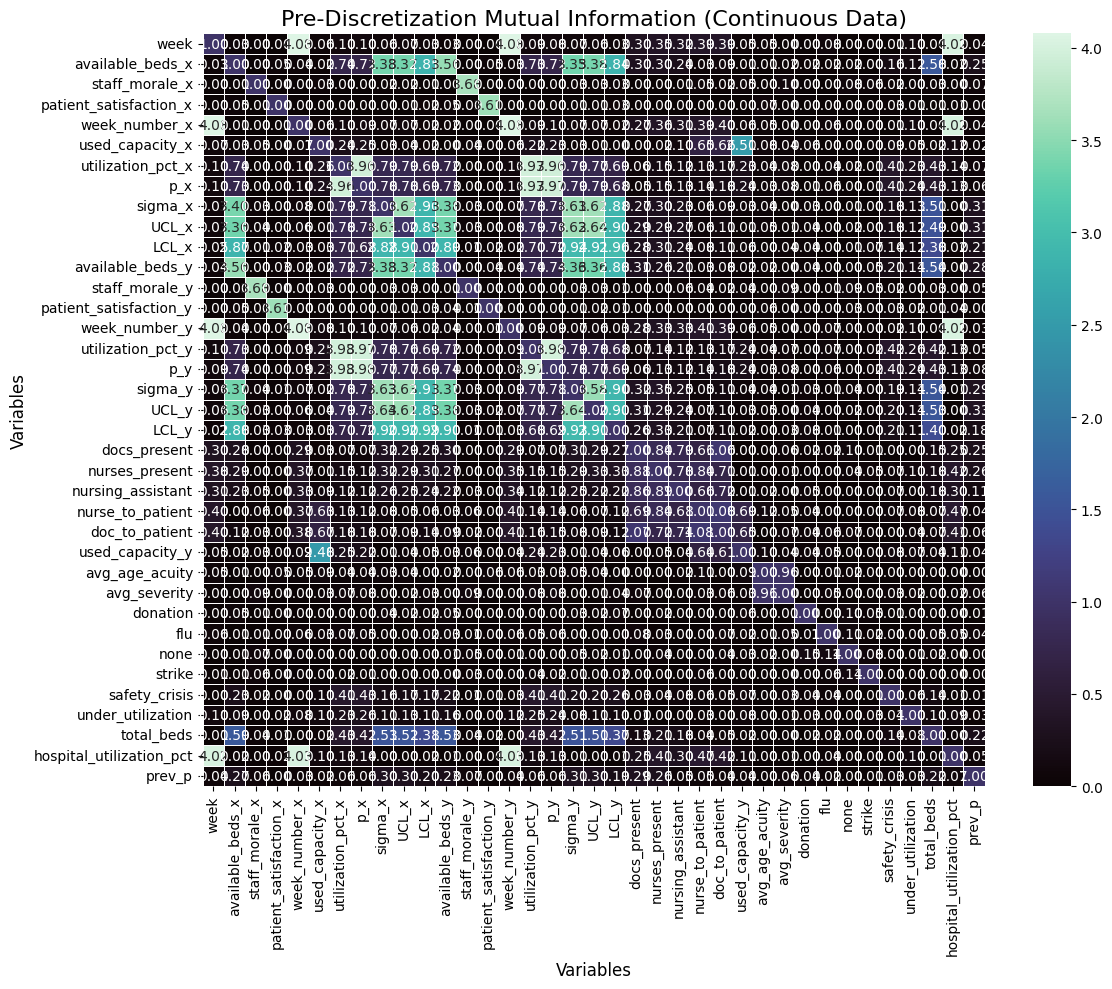

In [64]:

# 1. Calculate the Pairwise Mutual Information Matrix for continuous data
# We use numeric_df (before discretization)
numeric_df = master_df.select_dtypes(include=['number'])
nodes = numeric_df.columns
mi_matrix = pd.DataFrame(np.zeros((len(nodes), len(nodes))), index=nodes, columns=nodes)

for i in nodes:
    for j in nodes:
        if i == j:
            mi_matrix.loc[i, j] = 1.0 # Diagonal
        else:
            # mutual_info_regression is used for continuous vs continuous
            # We drop NaNs per pair to maximize data usage
            pair_df = numeric_df[[i, j]].dropna()
            if not pair_df.empty:
                score = mutual_info_regression(pair_df[[i]], pair_df[j])
                mi_matrix.loc[i, j] = score[0]

# 2. Plotting the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(mi_matrix, annot=True, cmap='mako', fmt=".2f", linewidths=.5)
plt.title('Pre-Discretization Mutual Information (Continuous Data)', fontsize=16)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()

# Save for the report
plt.savefig('mi_heatmap_continuous.png')

## Bayesian Decision support


Building and using a Bayesian Network consisting of discrete variables is essentially a three-stage process. The first stage includes the determination of the variables and their cause–effect relationships, while the second stage includes the specifications of each variable state’s conditional probability, given the state of the parent variables. The third stage is inference, during which the input data is entered to the Bayesian Network model and the probabilities for all Network nodes are calculated according to the cause–effect relationships. -https://www.sciencedirect.com/science/article/pii/S1532046405001097

### Variable binarization

In [28]:
master_df

,week,service,available_beds_x,staff_morale_x,patient_satisfaction_x,week_number_x,used_capacity_x,utilization_pct_x,p_x,sigma_x,...,avg_severity,week_start,donation,flu,none,strike,safety_crisis,under_utilization,total_beds,hospital_utilization_pct
0,1,emergency,32,70,67,1,2,6.250000,0.062500,0.082603,...,2.000000,2024-12-30,0,0,1,0,0,1,34,6.206897
1,1,surgery,45,78,83,1,2,4.444444,0.044444,0.069657,...,5.500000,2024-12-30,0,1,0,0,0,1,47,6.206897
2,1,general_medicine,37,43,97,1,2,5.405405,0.054054,0.076820,...,4.000000,2024-12-30,0,1,0,0,0,1,39,6.206897
3,1,ICU,22,91,84,1,3,13.636364,0.136364,0.099623,...,4.666667,2024-12-30,0,1,0,0,0,0,25,6.206897
4,2,emergency,28,64,75,2,5,17.857143,0.178571,0.088307,...,4.600000,2025-01-06,0,0,1,0,0,0,33,17.532468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,51,ICU,18,80,87,51,12,66.666667,0.666667,0.110138,...,5.666667,2025-12-15,0,0,1,0,1,0,30,15.068493
204,52,emergency,26,63,88,52,9,34.615385,0.346154,0.091640,...,5.000000,2025-12-22,0,0,1,0,0,0,35,16.161616
205,52,surgery,53,50,82,52,6,11.320755,0.113208,0.064185,...,4.333333,2025-12-22,0,0,1,0,0,1,59,16.161616
206,52,general_medicine,65,40,82,52,6,9.230769,0.092308,0.057958,...,6.000000,2025-12-22,0,1,0,0,0,1,71,16.161616


In [29]:

# Assuming master_df is your merged dataframe
df_bn = pd.DataFrame()

# Seasonality: Quarter-based binning
df_bn['season'] = pd.cut(master_df['week'], bins=[0, 13, 26, 39, 53], 
                         labels=['Q1', 'Q2', 'Q3', 'Q4'], include_lowest=True)

# Flu Events: Using quantiles to define 'Low', 'Med', 'High'#
df_bn['event_flu'] = pd.cut(
    master_df['flu'], 
    bins=[-1, 0, 1, 2], 
    labels=['Low', 'Med', 'High']
)
# Severity: Thresholds for clinical risk
df_bn['severity'] = pd.cut(master_df['avg_severity'], bins=[-1, 4, 7, 11], 
                           labels=['Stable', 'Elevated', 'Critical'])

# Previous Pressure: Last week's occupancy
master_df['prev_p'] = master_df.groupby('week')['p_x'].shift(1).fillna(master_df['p_x'].mean())
df_bn['prev_pressure'] = pd.cut(master_df['prev_p'], bins=[-1, 0.35, 0.85, 2.0], 
                                labels=['Under', 'Normal', 'Full'])

#Hospital Utilization
df_bn['hospital_utilization'] = pd.cut(master_df['p_x'], 
                                        bins=[-1, 0.4, 0.7, 1.1], 
                                        labels=['Low', 'Medium', 'High'])


# Target: Safety Crisis (Boolean to String for clarity)
df_bn['safety_crisis'] = master_df['safety_crisis'].map({1: 'Crisis', 0: 'Safe'})

#Staff Morale 
df_bn['morale'] = pd.cut(master_df['staff_morale_x'], 
                             bins=[-1, 50, 80, 110], 
                             labels=['Low', 'Medium', 'High'])

# Nurse Ratio (3 levels)
df_bn['nurse_load'] = pd.cut(master_df['nurse_to_patient'], 
                                bins=[-1, 0.5, 1, 100], 
                                labels=['Good', 'Heavy', 'Overloaded'])

# Doctor Ratio (3 levels)
df_bn['doctor_load'] = pd.cut(master_df['doc_to_patient'], 
                                bins=[-1, 2, 4, 100], 
                                labels=['Good', 'Heavy', 'Overloaded'])

# Patient Satisfaction
df_bn['satisfaction'] = pd.cut(master_df['patient_satisfaction_x'], 
                                   bins=[-1, 50, 80, 110], 
                                   labels=['Unhappy', 'Neutral', 'Happy'])

# Clean up any NaNs created by the shift
df_bn = df_bn.dropna()

df_bn

,season,event_flu,severity,prev_pressure,hospital_utilization,safety_crisis,morale,nurse_load,doctor_load,satisfaction
0,Q1,Low,Stable,Normal,Low,Safe,Medium,Good,Good,Neutral
1,Q1,Med,Elevated,Under,Low,Safe,Medium,Good,Good,Happy
2,Q1,Med,Stable,Under,Low,Safe,Low,Good,Good,Happy
3,Q1,Med,Elevated,Under,Low,Safe,High,Good,Good,Happy
4,Q1,Low,Elevated,Normal,Low,Safe,Medium,Good,Good,Neutral
...,...,...,...,...,...,...,...,...,...,...
203,Q4,Low,Elevated,Under,Medium,Crisis,Medium,Good,Good,Happy
204,Q4,Low,Elevated,Normal,Low,Safe,Medium,Good,Good,Happy
205,Q4,Low,Elevated,Under,Low,Safe,Low,Good,Heavy,Happy
206,Q4,Med,Elevated,Under,Low,Safe,Low,Good,Good,Happy


In [30]:
print(f"Rows before dropna: {len(master_df)}")
print(f"Rows after dropna: {len(df_bn)}")
print("\nMissing values per column before dropna:")
print(df_bn.isna().sum())

Rows before dropna: 208
Rows after dropna: 203

Missing values per column before dropna:
season                  0
event_flu               0
severity                0
prev_pressure           0
hospital_utilization    0
safety_crisis           0
morale                  0
nurse_load              0
doctor_load             0
satisfaction            0
dtype: int64


### Finding Optimal model

The following program looks for the most likely dependencies or links between data and recommends the casual nodes. We will take these into account and add some based on our knowledge and intuition of how a hospital works. With this we can model the probability of different events happening. 

In [31]:
from pgmpy.estimators import HillClimbSearch
#from pgmpy.estimators import 

# This will suggest the most likely 'Arrows' based on your data
hc = HillClimbSearch(df_bn)
best_model = hc.estimate(scoring_method="bic-d")
print("Suggested Causal Edges:", best_model.edges())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}
  0%|          | 4/1000000 [00:00<44:29:27,  6.24it/s] 

Suggested Causal Edges: [('season', 'event_flu'), ('safety_crisis', 'hospital_utilization'), ('safety_crisis', 'nurse_load'), ('nurse_load', 'doctor_load')]


In [58]:
recommended_model_edges = [
    ('season', 'event_flu'),                    # Suggested by algorithm
    ('safety_crisis', 'hospital_utilization'),  # Suggested by algorithm
    ('safety_crisis','nurse_load'),             # Suggested by algorithm
    ('nurse_load', 'doctor_load')   ,           # Suggested by algorithm
]

rec_utilz_model = DiscreteBayesianNetwork(recommended_model_edges)
rec_utilz_model.fit(df_bn, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
rec_inference = VariableElimination(rec_utilz_model)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}


In [ ]:
from pgmpy.metrics import log_likelihood_score
from pgmpy.metrics import structure_score
from pgmpy.metrics.bn_inference import BayesianModelProbability

# Ensure you are using your binned/categorical dataframe
rec_log_lik = log_likelihood_score(rec_utilz_model, df_bn)
rec_Bay_prob = BayesianModelProbability(rec_utilz_model)
rec_log_prob = rec_Bay_prob.log_probability(df_bn, ordering=None)
rec_score_prob = rec_Bay_prob.score(df_bn, ordering=None)
#struc_score = structure_score(final_utilz_model, df_bn, scoring_method="bic-g")
print(f"Log-Likelihood: {rec_log_lik:.2f}") # Higher is better

NameError: name 'rec_log_lik' is not defined

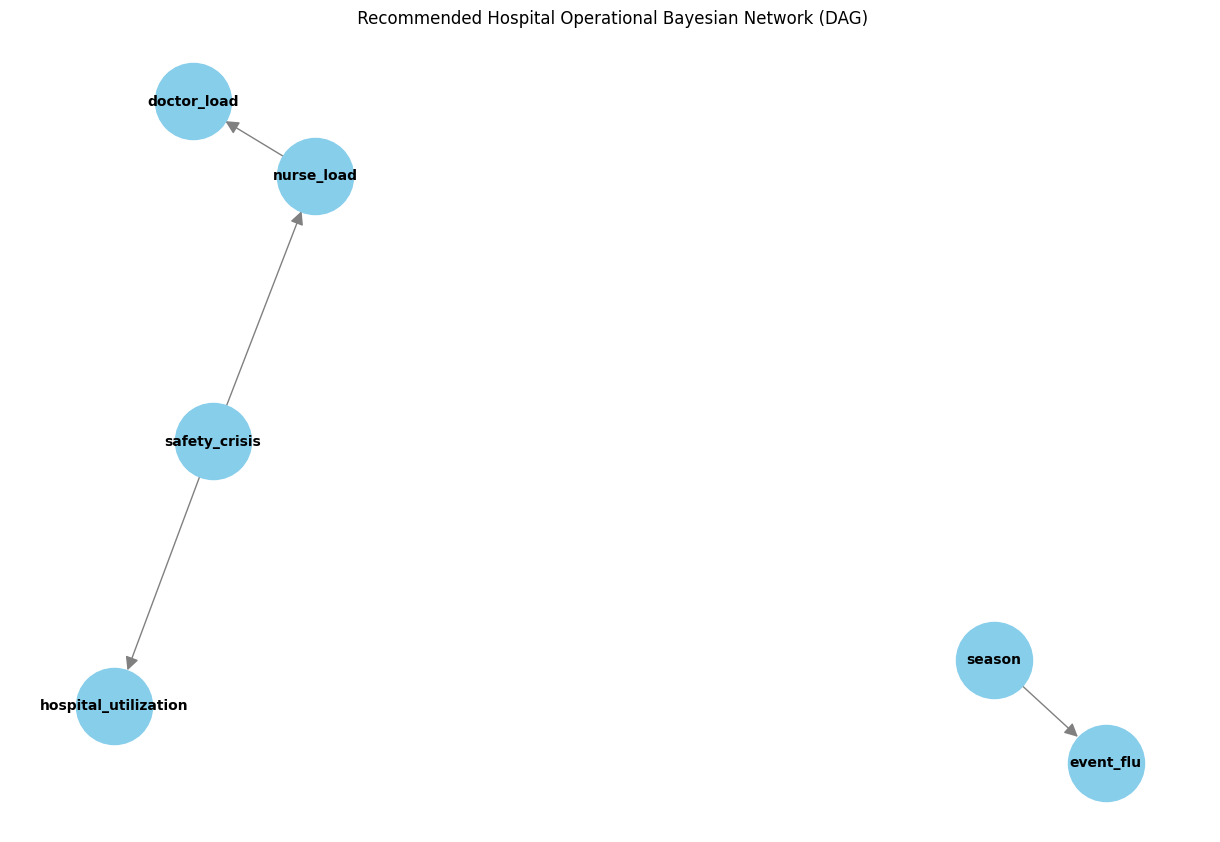

In [62]:
import networkx as nx
import matplotlib.pyplot as plt

# Create the graph object
rec_graph = nx.DiGraph(rec_utilz_model.edges())

# Define a layout (Kamada-Kawai or shell layout usually looks best for DAGs)
pos = nx.spring_layout(rec_graph, seed=42) 

plt.figure(figsize=(12, 8))
nx.draw(rec_graph, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_weight="bold", arrowsize=20, edge_color="gray")

plt.title(" Recommended Hospital Operational Bayesian Network (DAG)")
plt.show()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}
  0%|          | 4/1000000 [00:00<42:11:04,  6.58it/s] 


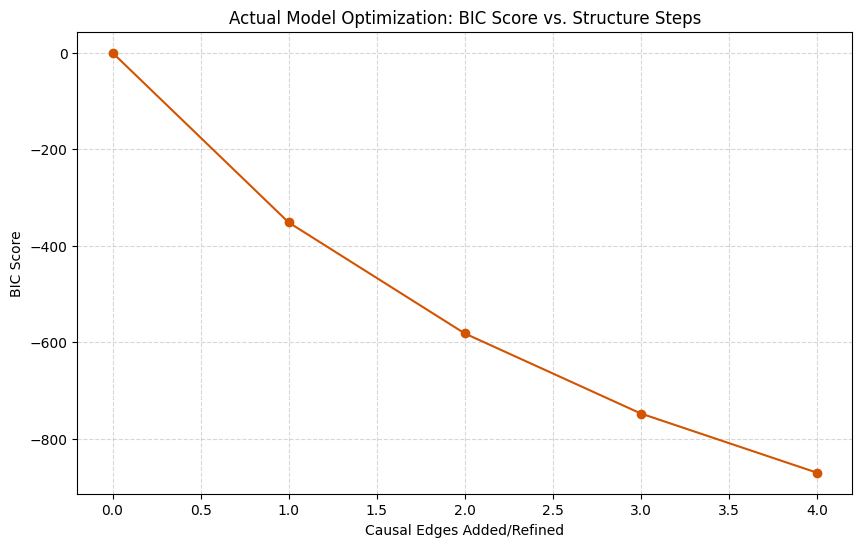

In [57]:
import matplotlib.pyplot as plt
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BIC

# 1. Initialize the scoring method and the search object
scoring_method=BIC(df_bn)
hc = HillClimbSearch(df_bn)

# 2. To get the steps, we can look at the internal 'iterations' or 
# manually calculate scores for the suggested edges
# However, HillClimbSearch is greedy; we can track its progress like this:
best_model = hc.estimate(scoring_method=scoring_method)

# To generate a plot of actual BIC improvements:
# We simulate the search steps to capture the score delta
model_edges = list(best_model.edges())
scores_history = []
current_edges = set()

# Start with empty graph score
scores_history.append(scoring_method.score(best_model.__class__()))

# Add edges one by one as the search would have done to see the score trend
# (Note: This is a simplified representation of the greedy path)
for edge in model_edges:
    current_edges.add(edge)
    temp_model = best_model.__class__(list(current_edges))
    scores_history.append(scoring_method.score(temp_model))

# 3. Plotting the actual data
plt.figure(figsize=(10, 6))
plt.plot(range(len(scores_history)), scores_history, marker='o', color='#d35400')
plt.title('Actual Model Optimization: BIC Score vs. Structure Steps')
plt.xlabel('Causal Edges Added/Refined')
plt.ylabel('BIC Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [32]:
# Create a hybrid model using the edges that made sense + your operational knowledge
final_model_edges = [
    ('season', 'event_flu'),                    # Suggested by algorithm
    ('season', 'hospital_utilization'),         # Added based on domain knowledge
    ('event_flu', 'hospital_utilization'),      
    ('hospital_utilization', 'safety_crisis'),  # Reversed from algorithm
    ('nurse_load', 'safety_crisis'),            # Reversed from algorithm
    ('doctor_load', 'safety_crisis'),           # Reversed from algorithm
    ('severity', 'morale'),                     # Added based on domain knowledge
    ('nurse_load', 'morale'),                   # Added based on domain knowledge
    ('doctor_load', 'morale'),                  # Added based on domain knowledge
    ('morale', 'satisfaction'),                
    ('safety_crisis', 'satisfaction'), 
    ('prev_pressure', 'hospital_utilization')  # Added based on domain knowledge   
]

final_utilz_model = DiscreteBayesianNetwork(final_model_edges)
final_utilz_model.fit(df_bn, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)
final_inference = VariableElimination(final_utilz_model)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}


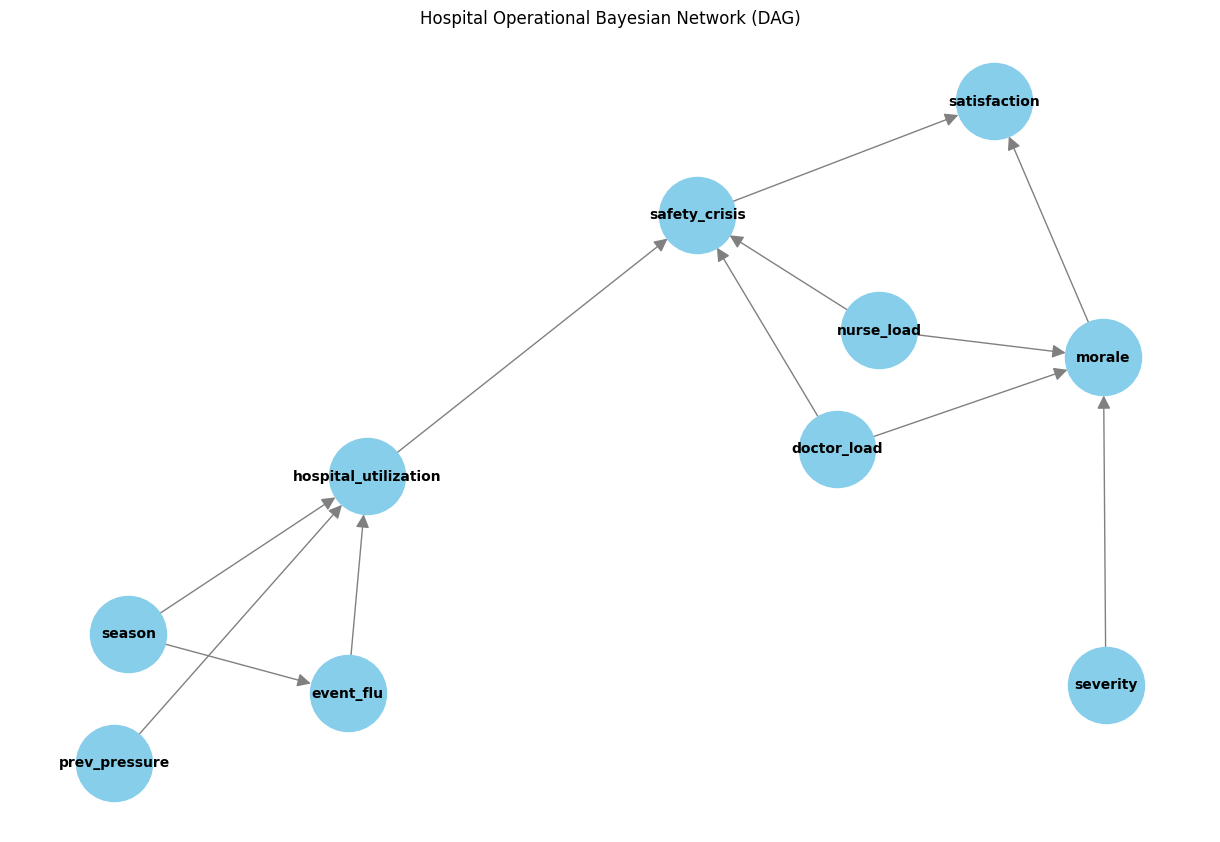

In [ ]:

# Create the graph object
G = nx.DiGraph(final_utilz_model.edges())

# Define a layout (Kamada-Kawai or shell layout usually looks best for DAGs)
pos = nx.spring_layout(G, seed=42) 

plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=10, font_weight="bold", arrowsize=20, edge_color="gray")

plt.title("Hospital Operational Bayesian Network (DAG)")
plt.show()

Based on the graph, we can see that there are three main factors that can be predicted with the information that we have subdivided into bins. The features that we can predict based on different combinations are *hospital utilization*, *safety crisis*, and *satisfaction*. We will make a scoring function to see how well the model fits the data. We will then do some queries to the model that would help a manager to generate the decision support. 

In [34]:
from pgmpy.metrics import log_likelihood_score
from pgmpy.metrics import structure_score
from pgmpy.metrics.bn_inference import BayesianModelProbability

# Ensure you are using your binned/categorical dataframe
log_lik = log_likelihood_score(final_utilz_model, df_bn)
Bay_prob = BayesianModelProbability(final_utilz_model)
log_prob = Bay_prob.log_probability(df_bn, ordering=None)
score_prob = Bay_prob.score(df_bn, ordering=None)
#struc_score = structure_score(final_utilz_model, df_bn, scoring_method="bic-g")


print(f"Log-Likelihood: {log_lik:.2f}") # Higher is better
print("Log-Probability:") # Higher is better
print(log_prob)
print("Score Probability:") # Higher is better
print(score_prob)


Log-Likelihood: -1391.04
Log-Probability:
[ -7.55775783  -6.25705435  -9.16014658  -6.46427994  -5.28840449
  -6.62798298  -8.78436721  -6.31697604  -6.09299728  -8.09119827
  -5.30909488  -6.14429945  -5.39689009 -10.37068316  -6.23636395
 -10.26659501  -6.11368767  -8.83248216  -5.28840449  -5.93278672
  -6.09299728  -7.90752081  -8.8286049   -5.93707386  -7.54245903
  -6.38419333  -5.76011013  -6.63695653  -7.66980628 -10.29102104
  -6.70786443  -8.37967398  -6.32329414  -6.49597073  -5.28840449
  -7.17740421  -8.00608316  -8.82217827  -5.64067974  -5.93707386
  -7.00593299  -7.76777022  -5.61998935  -8.9294696   -6.49358986
  -5.28840449  -5.93278672  -8.46438672  -5.68899707  -7.46984787
  -8.8682818   -8.36473149  -6.25067167  -6.98897175  -6.41033424
  -7.24164544  -6.24621134  -7.5202995   -7.63783972  -6.26324091
  -5.62458719  -9.20518532  -6.41033424  -8.29589795  -5.24468501
  -8.07681199  -9.15938917  -8.39362202  -5.24468501  -5.4519106
  -5.3352358   -8.47684417  -8.6520

In [35]:


# Query: Probability of Crisis given High Utilization and Critical Severity
query1 = final_inference.query(
    variables=['safety_crisis'], 
    evidence={'hospital_utilization': 'High', 'severity': 'Critical'}
)

print("1. CRISIS RISK ASSESSMENT - probability of safety_crisis given High Utilization & Critical Severity:")
print(query1)

1. CRISIS RISK ASSESSMENT - probability of safety_crisis given High Utilization & Critical Severity:
+-----------------------+----------------------+
| safety_crisis         |   phi(safety_crisis) |
+=======================+======================+
| safety_crisis(Crisis) |               0.8299 |
+-----------------------+----------------------+
| safety_crisis(Safe)   |               0.1701 |
+-----------------------+----------------------+


In [36]:
# Query: How does 'Overloaded' nurse staffing affect 'Happy' satisfaction?
query2 = final_inference.query(
    variables=['satisfaction'], 
    evidence={'nurse_load': 'Overloaded'}
)
query2_1 = final_inference.query(
    variables=['satisfaction'],
    evidence={'nurse_load': 'Good'}
)

print("\n2. STAFFING IMPACT ON PATIENT EXPERIENCE - probability of satisfaction given Overloaded Nurse Load:")
print(query2)
print("\nComparison with Good Nurse Load:")
print(query2_1)

# Pro-tip: Compare this to evidence={'nurse_load': 'Good'} to show the 'Satisfaction Gap'


2. STAFFING IMPACT ON PATIENT EXPERIENCE - probability of satisfaction given Overloaded Nurse Load:
+-----------------------+---------------------+
| satisfaction          |   phi(satisfaction) |
+=======================+=====================+
| satisfaction(Happy)   |              0.5156 |
+-----------------------+---------------------+
| satisfaction(Neutral) |              0.4844 |
+-----------------------+---------------------+

Comparison with Good Nurse Load:
+-----------------------+---------------------+
| satisfaction          |   phi(satisfaction) |
+=======================+=====================+
| satisfaction(Happy)   |              0.5127 |
+-----------------------+---------------------+
| satisfaction(Neutral) |              0.4873 |
+-----------------------+---------------------+


In [37]:
# Query: Expected occupancy/utilization state during Q1 (Flu Season)
query3 = final_inference.query(
    variables=['hospital_utilization'], 
    evidence={'season': 'Q1', 'event_flu': 'Med'}
)

print("\n3. SEASONAL CAPACITY FORECAST (Q1)")
print(query3)


3. SEASONAL CAPACITY FORECAST (Q1)
+------------------------------+-----------------------------+
| hospital_utilization         |   phi(hospital_utilization) |
+==============================+=============================+
| hospital_utilization(High)   |                      0.0854 |
+------------------------------+-----------------------------+
| hospital_utilization(Low)    |                      0.7353 |
+------------------------------+-----------------------------+
| hospital_utilization(Medium) |                      0.1793 |
+------------------------------+-----------------------------+


In [38]:
# Query: Probability of Hospital Utilization given Q2 and High Previous Pressure
q_utilization = final_inference.query(
    variables=['hospital_utilization'], 
    evidence={'season': 'Q3', 'prev_pressure': 'Full'}
)

print("--- PROBABILITY OF UTILIZATION (Q2 & PREVIOUSLY FULL) ---")
print(q_utilization)

# To extract the specific probability of 'High Pressure'
state_names = q_utilization.state_names['hospital_utilization']
high_util_idx = state_names.index('High')
prob_val = q_utilization.values[high_util_idx]

print(f"\nThe probability of High Utilization is: {prob_val:.2%}")

--- PROBABILITY OF UTILIZATION (Q2 & PREVIOUSLY FULL) ---
+------------------------------+-----------------------------+
| hospital_utilization         |   phi(hospital_utilization) |
+==============================+=============================+
| hospital_utilization(High)   |                      0.3333 |
+------------------------------+-----------------------------+
| hospital_utilization(Low)    |                      0.3333 |
+------------------------------+-----------------------------+
| hospital_utilization(Medium) |                      0.3333 |
+------------------------------+-----------------------------+

The probability of High Utilization is: 33.33%


### Interactive model 

This section makes a function to make the query system easier, the user must only place the target variable and the previous evidence to get a response from the system. 

In [39]:
def interactive_hospital_query(model, target_node, evidence_dict):
    """
    Returns the probability distribution for a target node given specific evidence.
    """
    from pgmpy.inference import VariableElimination
    
    # 1. Initialize Inference
    infer = VariableElimination(model)
    
    try:
        # 2. Perform the Query
        result = infer.query(variables=[target_node], evidence=evidence_dict)
        
        print(f"\n{'='*40}")
        print(f"INTERACTIVE QUERY RESULT")
        print(f"{'='*40}")
        print(f"Target:   {target_node.replace('_', ' ').title()}")
        print(f"Evidence: {evidence_dict}")
        print(f"{'-'*40}")
        print(result)
        
        # 3. Highlight the most likely outcome
        state_names = result.state_names[target_node]
        most_likely_idx = result.values.argmax()
        most_likely_state = state_names[most_likely_idx]
        prob = result.values[most_likely_idx]
        
        print(f"{'-'*40}")
        print(f"INSIGHT: The most likely outcome is '{most_likely_state}' ({prob:.1%})")
        print(f"{'='*40}")
        
    except ValueError as e:
        print(f"Error: {e}. Check if the variable names and states match your model exactly.")


In [40]:
# Get all available variables for the user to choose as a target
available_targets = list(final_utilz_model.nodes())

# Get all available states for a specific evidence node (e.g., 'season')
season_states = final_utilz_model.get_cpds('season').state_names['season']
event_flu_states = final_utilz_model.get_cpds('event_flu').state_names['event_flu']
hospital_util_states = final_utilz_model.get_cpds('hospital_utilization').state_names['hospital_utilization']
nurse_load_states = final_utilz_model.get_cpds('nurse_load').state_names['nurse_load']
doctor_load_states = final_utilz_model.get_cpds('doctor_load').state_names['doctor_load']
severity_states = final_utilz_model.get_cpds('severity').state_names['severity']
morale_states = final_utilz_model.get_cpds('morale').state_names['morale']
satisfaction_states = final_utilz_model.get_cpds('satisfaction').state_names['satisfaction']
prev_pressure_states = final_utilz_model.get_cpds('prev_pressure').state_names['prev_pressure']
print(available_targets)
print("Season States:", season_states)
print("Flu Event States:", event_flu_states)
print("Hospital Utilization States:", hospital_util_states)
print("Nurse Load States:", nurse_load_states)
print("Doctor Load States:", doctor_load_states)
print("Severity States:", severity_states)
print("Morale States:", morale_states)
print("Satisfaction States:", satisfaction_states)
print("Previous Pressure States:", prev_pressure_states)

['season', 'event_flu', 'hospital_utilization', 'safety_crisis', 'nurse_load', 'doctor_load', 'severity', 'morale', 'satisfaction', 'prev_pressure']
Season States: ['Q1', 'Q2', 'Q3', 'Q4']
Flu Event States: ['Low', 'Med']
Hospital Utilization States: ['High', 'Low', 'Medium']
Nurse Load States: ['Good', 'Heavy', 'Overloaded']
Doctor Load States: ['Good', 'Heavy', 'Overloaded']
Severity States: ['Critical', 'Elevated', 'Stable']
Morale States: ['High', 'Low', 'Medium']
Satisfaction States: ['Happy', 'Neutral']
Previous Pressure States: ['Full', 'Normal', 'Under']


In [53]:
# You can change these variables to test different scenarios
target = 'safety_crisis'
evidence = {'season': 'Q1', 'event_flu': 'Med', 'severity': 'Critical'}

interactive_hospital_query(final_utilz_model, target, evidence)


INTERACTIVE QUERY RESULT
Target:   Safety Crisis
Evidence: {'season': 'Q1', 'event_flu': 'Med', 'severity': 'Critical'}
----------------------------------------
+-----------------------+----------------------+
| safety_crisis         |   phi(safety_crisis) |
+=======================+======================+
| safety_crisis(Crisis) |               0.1430 |
+-----------------------+----------------------+
| safety_crisis(Safe)   |               0.8570 |
+-----------------------+----------------------+
----------------------------------------
INSIGHT: The most likely outcome is 'Safe' (85.7%)


### Finding alternative models

In [42]:
# Define the Structure (The DAG)
model = DiscreteBayesianNetwork([
     ('season', 'safety_crisis'),
     ('event_flu', 'safety_crisis'),
     ('severity', 'safety_crisis'),
     ('prev_pressure', 'safety_crisis')
 ])

 # Fit the Model (Learning the Conditional Probabilities)
# This step calculates how often a Crisis happens for every combination of inputs
model.fit(df_bn, estimator=MaximumLikelihoodEstimator)

# # 3. Initialize the Inference Engine
inference = VariableElimination(model)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}


In [43]:
# Define the structure
sat_model = DiscreteBayesianNetwork([
    ('severity', 'morale'),
    ('nurse_load', 'morale'),
    ('morale', 'satisfaction'),
    ('severity', 'satisfaction') # Sicker patients might be harder to satisfy regardless of morale
])

# Fit the model (Learning CPTs)
sat_model.fit(df_bn, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

# Initialize Inference
sat_infer = VariableElimination(sat_model)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}


In [44]:
# Define the structure
utilz_model = DiscreteBayesianNetwork([
   
    # Drivers of Utilization
    ('season', 'hospital_utilization'),
    ('event_flu', 'hospital_utilization'),
    ('prev_pressure', 'hospital_utilization'),
    
    # Impact on Safety
    ('hospital_utilization', 'safety_crisis'),
    ('severity', 'safety_crisis'),
    
    # Impact on Staff
    ('hospital_utilization', 'morale'),
    ('nurse_load', 'morale'),
    ('doctor_load', 'morale'),
    
    # Final Outcomes
    ('morale', 'satisfaction'),
    ('safety_crisis', 'satisfaction'),
    ('severity', 'satisfaction')
])

# Fit the model (Learning CPTs)
utilz_model.fit(df_bn, estimator=BayesianEstimator, prior_type='BDeu', equivalent_sample_size=10)

# Initialize Inference
utilz_infer = VariableElimination(utilz_model)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'season': 'O', 'event_flu': 'O', 'severity': 'O', 'prev_pressure': 'O', 'hospital_utilization': 'O', 'safety_crisis': 'C', 'morale': 'O', 'nurse_load': 'O', 'doctor_load': 'O', 'satisfaction': 'O'}


In [45]:
# Scenario A: Ideal Staffing (Nurse Load = Good)
prob_good_staffing = sat_infer.query(
    variables=['satisfaction'], 
    evidence={'nurse_load': 'Good'}
)

# Scenario B: Crisis Staffing (Nurse Load = Overloaded)
prob_bad_staffing = sat_infer.query(
    variables=['satisfaction'], 
    evidence={'nurse_load': 'Overloaded'}
)

print("--- IMPACT OF NURSE LOAD ON SATISFACTION ---")
print(f"\n[SCENARIO: GOOD STAFFING]")
print(prob_good_staffing)

print(f"\n[SCENARIO: OVERLOADED]")
print(prob_bad_staffing)

--- IMPACT OF NURSE LOAD ON SATISFACTION ---

[SCENARIO: GOOD STAFFING]
+-----------------------+---------------------+
| satisfaction          |   phi(satisfaction) |
+=======================+=====================+
| satisfaction(Happy)   |              0.5200 |
+-----------------------+---------------------+
| satisfaction(Neutral) |              0.4800 |
+-----------------------+---------------------+

[SCENARIO: OVERLOADED]
+-----------------------+---------------------+
| satisfaction          |   phi(satisfaction) |
+=======================+=====================+
| satisfaction(Happy)   |              0.5291 |
+-----------------------+---------------------+
| satisfaction(Neutral) |              0.4709 |
+-----------------------+---------------------+


In [46]:
# “What is the probability of a Safety Crisis if we have both a 'High' Flu count AND 'Critical' Patient Severity?”
Perfect_storm = inference.query(variables=['safety_crisis'], evidence={'event_flu': 'Med', 'severity': 'Critical'})
print("\n--- PERFECT STORM SCENARIO PROBABILITY ---")
print(Perfect_storm)


--- PERFECT STORM SCENARIO PROBABILITY ---
+-----------------------+----------------------+
| safety_crisis         |   phi(safety_crisis) |
+=======================+======================+
| safety_crisis(Crisis) |               0.5000 |
+-----------------------+----------------------+
| safety_crisis(Safe)   |               0.5000 |
+-----------------------+----------------------+


In [47]:
# “Given that we ended last week 'Full', how likely is a crisis this week even if events are 'Low'?”
next_week_crisis = inference.query(variables=['safety_crisis'], evidence={'prev_pressure': 'Full', 'event_flu': 'Low'})
print("\n--- NEXT WEEK CRISIS PROBABILITY ---")
print(next_week_crisis)


--- NEXT WEEK CRISIS PROBABILITY ---
+-----------------------+----------------------+
| safety_crisis         |   phi(safety_crisis) |
+=======================+======================+
| safety_crisis(Crisis) |               0.2806 |
+-----------------------+----------------------+
| safety_crisis(Safe)   |               0.7194 |
+-----------------------+----------------------+


In [48]:
# Probability of underutilization in Q1 vs Q3 
underutilization_q1 = utilz_infer.query(variables=['hospital_utilization'], evidence={'season': 'Q1'})
underutilization_q2 = utilz_infer.query(variables=['hospital_utilization'], evidence={'season': 'Q2'})
underutilization_q3 = utilz_infer.query(variables=['hospital_utilization'], evidence={'season': 'Q3'})
underutilization_q4 = utilz_infer.query(variables=['hospital_utilization'], evidence={'season': 'Q4'})
print("\n--- UNDERUTILIZATION PROBABILITY COMPARISON ---")
print(f"\n[Q1]")
print(underutilization_q1)
print(f"\n[Q2]")
print(underutilization_q2)



--- UNDERUTILIZATION PROBABILITY COMPARISON ---

[Q1]
+------------------------------+-----------------------------+
| hospital_utilization         |   phi(hospital_utilization) |
+==============================+=============================+
| hospital_utilization(High)   |                      0.1087 |
+------------------------------+-----------------------------+
| hospital_utilization(Low)    |                      0.5931 |
+------------------------------+-----------------------------+
| hospital_utilization(Medium) |                      0.2983 |
+------------------------------+-----------------------------+

[Q2]
+------------------------------+-----------------------------+
| hospital_utilization         |   phi(hospital_utilization) |
+==============================+=============================+
| hospital_utilization(High)   |                      0.2033 |
+------------------------------+-----------------------------+
| hospital_utilization(Low)    |                      0.5

In [49]:
print(f"\n[Q3]")
print(underutilization_q3)
print(f"\n[Q4]")
print(underutilization_q4)


[Q3]
+------------------------------+-----------------------------+
| hospital_utilization         |   phi(hospital_utilization) |
+==============================+=============================+
| hospital_utilization(High)   |                      0.1432 |
+------------------------------+-----------------------------+
| hospital_utilization(Low)    |                      0.4417 |
+------------------------------+-----------------------------+
| hospital_utilization(Medium) |                      0.4151 |
+------------------------------+-----------------------------+

[Q4]
+------------------------------+-----------------------------+
| hospital_utilization         |   phi(hospital_utilization) |
+==============================+=============================+
| hospital_utilization(High)   |                      0.0939 |
+------------------------------+-----------------------------+
| hospital_utilization(Low)    |                      0.5782 |
+------------------------------+-----------

## nrcy


In [50]:

# 1. Load your dataset

# 2. Discretize the data for the Bayesian Network
# We transform 'patients_request' and 'staff_morale' into categorical bins
df['request_level'] = pd.qcut(df['patients_request'], q=3, labels=['Low', 'Medium', 'High'])
df['morale_level'] = pd.qcut(df['staff_morale'], q=3, labels=['Low', 'Medium', 'High'])

# 3. Define the Network Structure
# We assume that Patient Requests influence Staff Morale
model = DiscreteBayesianNetwork([('request_level', 'morale_level')])

# 4. Fit the model using the data
# This calculates the Conditional Probability Tables (CPTs) automatically
model.fit(df, estimator=MaximumLikelihoodEstimator)

# 5. Set up the Inference engine
inference = VariableElimination(model)

# 6. Query the model: 
# "What is the probability of Low Morale if we have a High level of requests?"
result_High = inference.query(
    variables=['morale_level'], 
    evidence={'request_level': 'High'}
)
result_Low = inference.query(
    variables=['morale_level'], 
    evidence={'request_level': 'Low'}
)

print("Probability of Morale Levels given High Requests:")
print(result_High)
print("Probability of Morale Levels given Low Requests:")
print(result_Low)

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination

# 1. Load data
df = pd.read_csv('data/services_weekly.csv')

# 2. Discretize into 3 categories: Low, Medium, High
df['request_level'] = pd.qcut(df['patients_request'], q=3, labels=['Low', 'Medium', 'High'])
df['bed_level'] = pd.qcut(df['available_beds'], q=3, labels=['Low', 'Medium', 'High'])
df['morale_level'] = pd.qcut(df['staff_morale'], q=3, labels=['Low', 'Medium', 'High'])

# 3. Define a more complex structure: 
# Both 'requests' and 'beds' influence 'morale'
model = DiscreteBayesianNetwork([
    ('request_level', 'morale_level'),
    ('bed_level', 'morale_level')
])

# 4. Fit the model
model.fit(df, estimator=MaximumLikelihoodEstimator)
inference = VariableElimination(model)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'week': 'N', 'month': 'N', 'service': 'C', 'available_beds': 'N', 'patients_request': 'N', 'patients_admitted': 'N', 'patients_refused': 'N', 'patient_satisfaction': 'N', 'staff_morale': 'N', 'event': 'C', 'request_level': 'O', 'bed_level': 'O', 'morale_level': 'O'}


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import model_selection
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge

# Plotting style
sns.set_style('darkgrid')
sns.set_theme(font_scale=1.)

def setup_storage_for_experiment(K_outer, K_inner, num_hyperparams):
    # Setup storage for the optimal hyperparameters found from the inner CV
    optimal_hyperparameters = np.empty(K_outer)

    # Setup storage for model coefficients and errors for each experiment in all inner folds
    ws_inner = np.empty((M + 1, K_outer, K_inner, num_hyperparams))
    train_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))
    test_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))

    # Setup storage for model coefficients for each experiment in all outer folds
    ws_outer = {
        'not regularized': np.empty((M + 1, K_outer)),
        'regularized': np.empty((M + 1, K_outer))
    }
    # Setup storage for errors as a dictionary
    errors_outer = {
        'train': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        },
        'test': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        }
    }
    return optimal_hyperparameters, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer

def print_regularization_results(errors):
    # Display results
    print("Linear regression without regularization:")
    print(f"- Training error: \t{errors['train']['not regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['not regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['not regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['not regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

    print("Regularized linear regression:")
    print(f"- Training error: \t{errors['train']['regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

def get_grid_points(x_min, x_max, y_min, y_max, delta=5e-3):
    # Create a grid of points with the specified resolution
    xx = np.arange(x_min, x_max, delta)
    yy = np.arange(y_min, y_max, delta)
    # Make a mesh-grid that spans the grid-range defined
    grid = np.stack(np.meshgrid(xx, yy))
    return grid, xx, yy

def plot_decision_boundary(predict_function, X, threshold=None, ax=None, fig=None, cmap='RdBu_r'):
    # Set grid range based on the data
    grid_range = [X[:, 0].min(), X[:, 0].max(), X[:, 1].min(), X[:, 1].max()]  # [x_min, x_max, y_min, y_max]
    # Add 10% margin to the grid range to ensure points on the edge are included
    margin_x = 0.1 * (grid_range[1] - grid_range[0])
    margin_y = 0.1 * (grid_range[3] - grid_range[2])
    grid_range[0] -= margin_x
    grid_range[1] += margin_x
    grid_range[2] -= margin_y
    grid_range[3] += margin_y

    # Get grid points
    grid, xx, yy = get_grid_points(*grid_range, delta=5e-3)
    # Reshape grid to a list of points
    grid_points = np.reshape(grid, (2, -1)).T

    # Compute model predictions on the grid points (i.e. the probability of class 1)
    grid_predictions = predict_function(grid_points)

    # Reshape the predictions back to the grid shape
    decision_boundary = np.reshape(grid_predictions, (len(yy), len(xx)))

    # Plot the decision boundary
    img = ax.imshow(decision_boundary, extent=grid_range, origin='lower', cmap=cmap, alpha=0.5, vmin=0, vmax=1)
    fig.colorbar(img, ax=ax)
    if threshold is not None:
        ax.contour(grid[0], grid[1], decision_boundary, levels=[threshold], colors='k')
    ax.grid(False)
    ax.set_aspect('auto')

# Introduction

We previously studied how models can easily overfit the training data if the model is too flexible. We argued that we can mitigate overfitting, by using larger datasets or simplifying the model, e.g. by reducing the number of parameters in linear models. These strategies apply broadly across modeling techniques. However, collecting more data can be expensive and in some settings we might need a highly flexible model to be able to fit complex data. In this exercise, we will study other approaches to reducing overfitting - specifically, we will consider techniques that *trade off model variance with model bias*.

Bias and variance describe how well a model generalizes beyond its training data:
- **Bias** relates to *how well the model fits the training data*. The better it fits this data, the *lower* the bias is. A too simple model (*high bias*) might not fit the data which results in *underfitting*.
- **Variance** relates to the *flexibility of the model when we train it on a new data set*. If we train a model on new training sets, their outputs can be very different as the model's parameters have greater variance. This relates to *overfitting*.

The fact that we can not prevent under- and overfitting simultaneously is why we call it *the bias–variance trade-off*. Reducing variance usually increases bias, and reducing bias usually increases variance. Therefore we need to find a balance where the model captures real patterns without overfitting to noise in the data.

Alternatively, one can combine the predictions of multiple models in an *ensemble*. This can reduce model variance without greatly increasing bias which can give better generalization performance.


---
## Part 1: Regularization for trading of variance with bias

An approach to control for the complexity of the model is to regularize the parameters in the objective function. For instance for linear regression we can regularize the parameters $\boldsymbol{w}$ by the Frobenius norm, which essentially forces the model to be less flexible but with the benefit that it is also less likely to overfit. By regularizing the weights in this manner, the considered cost function is the mean squared error with an additional term, i.e.:
$$
\begin{align*}
    E\left(\boldsymbol{X}, \boldsymbol{y}, \boldsymbol{w}\right) &=\sum_n \|y_n -\boldsymbol{x}_n^{\top}\boldsymbol{w}\|_F^2+\lambda \|\boldsymbol{w}\|_F^2 =\sum_n (y_n -\boldsymbol{x}_n^{\top}\boldsymbol{w})^2+\lambda \underset{=\lVert \boldsymbol{w}\rVert_2^2}{\underbrace{\boldsymbol{w}^{\top}\boldsymbol{w}}}
\end{align*}
$$
where $\left(\boldsymbol{X}, \boldsymbol{y}\right)$ is the data matrix and target vector. Solving the equation $\frac{\partial E}{\partial \boldsymbol{w}}=0$ we obtain $\boldsymbol{w}=(\boldsymbol{X}^\top\boldsymbol{X}+\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^\top\boldsymbol{y}$ (see also the lecture slides for today). This type of regularization is commonly known as *ridge regularization* 

When regularizing a model as above we apply the same regularization strength to all features, and so it is important to standardize the features. Note that if we include a bias term (offset/intercept) we do not regularize it. In the following, we will see how regularization can help us to avoid overfitting by trading off model variance with bias. For doing so, we revisit the polynomial dataset from week 6.

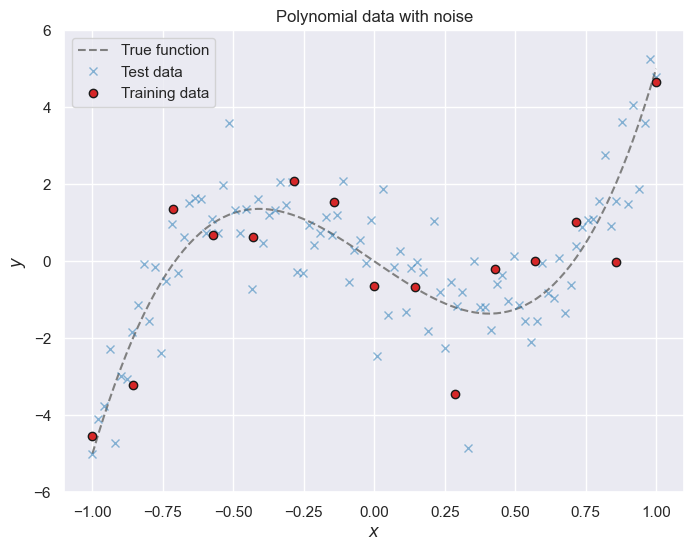

In [ ]:
# Set random seed for reproducibility
np.random.seed(1234)

# Define data-generating function
func = lambda x: 10 * x**3 - 5 * x

# Generate training data from polynomial
N_train = 15
X_train = np.linspace(-1, 1, N_train).reshape(-1,1) # Training inputs
y_train = func(X_train) + np.random.randn(N_train).reshape(-1,1) # Training outputs with noise
# Generate test data from polynomial
N_test = 100
X_test = np.linspace(-1,1, N_test).reshape(-1,1) # Test inputs
y_test = func(X_test) + np.random.randn(N_test).reshape(-1,1) # Test outputs with noise

# Define a function for plotting the data
def plot_polynomial_data(X_train, y_train, X_test, y_test, func, plot_test_points=True, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Plot true function and data points
    ax.plot(X_test, func(X_test), "--", color="gray", label="True function")
    if plot_test_points: # only plot test points if specified
        ax.plot(X_test, y_test, "x", color="tab:blue", label="Test data", alpha=0.5)
    
    # Plot training points
    ax.plot(X_train, y_train, "o", color="tab:red", label="Training data", mec='k')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_ylim(-6, 6)

# Plot the data using the function
fig, ax = plt.subplots(figsize=(8, 6))
plot_polynomial_data(X_train, y_train, X_test, y_test=y_test, func=func, ax=ax)
ax.set_title("Polynomial data with noise")
ax.legend()
plt.show()

**Task 1.1:** Fit a linear regression model with polynomial features to the data.

> *Hint:* We use a polynomial degree that is the same as the number of training points, i.e. $15$.

> *Hint:* Use `model = make_pipeline(PolynomialFeatures(degree), LinearRegression())` to construct a linear regression model with polynomial features.

> *Hint:* Next, fit the model using `model.fit()`.

<br>

**Task 1.2:** Compute the mean squared error (MSE) on the training and test set. The training MSE should be 0 - why is that?

> *Hint:* Remember from the week on overfitting, that a model with equally many parameters as data points perfectly fits the training data.

In [ ]:
degree = N_train

# Create a linear regression model with polynomial features of some degree
# YOUR CODE HERE
raise NotImplementedError()


# Extract model coefficients
coefs = model.named_steps['linearregression'].coef_.flatten()

# Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [2, 1]})
# Plot the learned polynomial function
x_grid = np.linspace(-1, 1, 1000).reshape(-1,1)
axs[0].plot(x_grid, model.predict(x_grid), color="tab:green", label=f"Fitted model")
# Re-plot the data
plot_polynomial_data(X_train, y_train, X_test, y_test, func, ax=axs[0])
# Add title and legend
axs[0].set_title(f"Linear model with degree {degree}")
axs[0].legend(loc='upper left')

# Plot the model coefficients
axs[1].stem(coefs)
axs[1].set_title(r"Model coefficients, $\boldsymbol{w}$")
axs[1].set_xlabel("Coefficient index")
axs[1].set_ylabel("Coefficient value")
plt.show()


# Predict on the training and test data and compute MSE
# YOUR CODE HERE
raise NotImplementedError()

NotImplementedError: 

Currently, we have a very flexible model (high variance) due to the fact that we have as many parameters as training data points. This makes us overfit to the training data. In the beginning of the exercise, we argued that *regularizing* the model weights by enforcing the coefficients/weights to have a low $\ell_2$ norm. This can help us trade-off variance with bias and thereby avoid overfitting.

**Task 1.3:** Introduce regularization by the $\ell_2$-norm on the weights using a regularization strength of $\lambda=0.001$ and repeat the two previous tasks. How does this impact the model visually (model fit and coefficients)? How does this impact the models training and test set errors?

> *Hint:* We need to change the model type to the `sklearn.linear_model.Ridge()` which is equivalent to linear regression with $\ell_2$ regularization. Remark that this function denotes the regularization strength by the input argument `alpha`.

In [ ]:
degree = N_train
regularization_strength = 0.001

# Create a linear regression model with polynomial features of some degree
# YOUR CODE HERE
raise NotImplementedError()


# Extract model coefficients
coefs = model.named_steps['ridge'].coef_.flatten()

# Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [2, 1]})
# Plot the learned polynomial function
x_grid = np.linspace(-1, 1, 1000).reshape(-1,1)
axs[0].plot(x_grid, model.predict(x_grid), color="tab:green", label=f"Fitted model")
# Re-plot the data
plot_polynomial_data(X_train, y_train, X_test, y_test, func, ax=axs[0])
# Add title and legend
axs[0].set_title(f"Linear model with degree {degree}")
axs[0].legend(loc='upper left')

# Plot the model coefficients
axs[1].stem(coefs)
axs[1].set_title(r"Model coefficients, $\boldsymbol{w}$")
axs[1].set_xlabel("Coefficient index")
axs[1].set_ylabel("Coefficient value")
plt.show()


# Predict on the training and test data and compute MSE
# YOUR CODE HERE
raise NotImplementedError()

The fact that the regularization penalizes large coefficients means that the model has less wiggle-room (lower variance) which prevents the model from overfitting to the training points. This comes at the cost of increasing bias, since the model is constrained from fitting the training data as closely.

**Task 1.4:** What happens to the model fit if you increase the regularization strength $\lambda$ further? Try with $\lambda=0.1$ and $\lambda=10$. Which regularization strength would you choose and why?

> *Hint:* Do we choose the best value for $\lambda$ based on the training set MSE or test set MSE?

> *Hint:* What happens to the bias and variance when you increase the regularization strength?

- *Answer:*


---
## Part 2: Regression on the `body` dataset with regularizaton

In the following, we will see how to regularize a model for predicting a continous target variable using *linear* regression and its regularized version, namely ridge regression that we also considered above. We load the `body` dataset and use the $\left(\boldsymbol{X}, \boldsymbol{y}\right)$ convention. We choose the body weight as the target to learn and use the remaining features as the input data.

**Task 2.1:** Inspect the code cell below. Take a look at the attributes that we keep in the data matrix $\boldsymbol{X}$.

In [ ]:
# Load the body dataset
df = pd.read_csv('data/body.csv')
# Display the first few rows of the dataframe
display(df.head())

# Define feature matrix X and target vector y
X = df.drop(columns=['Offset', 'weight']).values
y = df['weight'].values

# Get number of samples and features
N, M = X.shape
print(f"Number of samples: {N}, number of features: {M}")

Notice that we remove the "Offset" attribute (the one related to the intercept) from the training data. This is because `Ridge()` and `LinearRegression()` internally fit the bias separately from the weights. In this way, `Ridge()` only regularizes the coefficients and not the intercept - note that we should **never regularize the bias!**

**Task 2.2:** Why might it be a good idea to add regularization to a linear model trained on the `body` dataset?

> *Hint:* How many observations does the dataset have? How many features?

- *Answer:*

We provide most code for doing two-layer cross-validation on the body data. In the inner loop, 10-fold cross-validation is used to select for the optimal value of regularization $\lambda$. In the outer loop 5-fold cross-validation is used to evaluate the model performance using the optimal selected value for $\lambda$. What the code cell does is to:
1. Define the cross-validation setup and the hyperparameters to test in the inner loop (here, the regularization strengths).
2. Make an outer train-test split of the data.
3. Split the outer training data into an inner train-test split. 
4. Standardize the inner train-test data wrt. the mean and standard deviation of the *inner training data*.
5. For each of the selected hyperparameter settings, train and evaluate a model on the inner data split.
6. Do this for all inner folds, then determine the optimal value of the hyperparameter based on the lowest *average test error across inner folds*.
7. Standardize the outer train-test data based on the mean and standard deviation of the *outer training data*, then train and evaluate a model on this data using the optimal hyperparameter value.
8. Train and evaluate a baseline model on the same dataset split for comparison. Store the result for both approaches. 
9. Repeat the procedure for all outer folds.

**Task 2.3:** Fill in the missing parts of the two-layer cross-validation.

> *Hint:* First task is to standardize the data in the inner fold. Notice where in the code we do this standardization. This is important for not leaking information from the test set dataset into the training dataset which would bias the generalization error.

> *Hint:* Next task is to fit the regularized model. Use the `sklearn.linear_model.Ridge()` model again, now without polynomial features.

> *Hint:* Third, determine the optimal regularization strength based on the average test set error. You can do `optimal_hyperparameter = lambdas[np.argmin(np.mean(test_errors_inner[outer_fold_idx], axis=0))]`.

> *Hint:* Now, standardize the data of the outer fold and train a model with the optimal regularization strength that you just found.

In [ ]:
# Set random seed for reproducibility
np.random.seed(1234)

# Create crossvalidation partition for model evaluation
K_outer = 5
CV_outer = model_selection.KFold(K_outer, shuffle=True)

# Create crossvalidation partition for hyperparameter tuning
K_inner = 10
CV_inner = model_selection.KFold(K_inner, shuffle=True)

# Values of regularization parameter lambda to test in the inner loop
lambdas = np.logspace(-5, 8, 14)

# Setup storage for the experiment
optimal_regularization_strengths, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer = setup_storage_for_experiment(K_outer, K_inner, len(lambdas))

# Run two-layer cross-validation
for outer_fold_idx, (outer_train_index, outer_test_index) in enumerate(CV_outer.split(X, y)):
    # Extract training and test set for the current outer CV fold
    X_train_outer, y_train_outer = X[outer_train_index], y[outer_train_index]
    X_test_outer, y_test_outer = X[outer_test_index], y[outer_test_index]

    # Loop over inner cross-validation folds
    for inner_fold_idx, (inner_train_index, inner_test_index) in enumerate(CV_inner.split(X_train_outer, y_train_outer)):

        # Extract training and validation set for current inner CV fold
        X_train_inner, y_train_inner = X_train_outer[inner_train_index], y_train_outer[inner_train_index]
        X_test_inner, y_test_inner = X_train_outer[inner_test_index], y_train_outer[inner_test_index]

        # Compute the mean and standard deviation of the inner training data split, then standardize training and test sets
        # YOUR CODE HERE
        raise NotImplementedError()

        # Loop over all values of lambda
        for lambda_idx, regularization_strength in enumerate(lambdas):

            # Create and fit the model
            # YOUR CODE HERE
            raise NotImplementedError()

            # Store the model coefficients for each value of lambda in the inner folds
            ws_inner[:, outer_fold_idx, inner_fold_idx, lambda_idx] = [model.intercept_] + model.coef_.flatten().tolist()

            # Compute and store the training and validation error
            train_errors_inner[outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean((y_train_inner - model.predict(X_train_inner))**2, axis=0)
            test_errors_inner[outer_fold_idx, inner_fold_idx, lambda_idx] = np.mean((y_test_inner - model.predict(X_test_inner))**2, axis=0)
    
    # Determine the optimal value of lambda that gives the lowest test error on average from the inner folds
    # YOUR CODE HERE
    raise NotImplementedError()

    # Store the optimal regularization strength for the current outer fold
    optimal_regularization_strengths[outer_fold_idx] = optimal_hyperparameter

    # Compute the mean and standard deviation of the outer training data split, then standardize the training and test sets
    # YOUR CODE HERE
    raise NotImplementedError()

    # Create and fit the model with the optimal lambda on the entire outer training set
    # YOUR CODE HERE
    raise NotImplementedError()

    # Store the model coefficients for the regularized model
    ws_outer['regularized'][:, outer_fold_idx] = [model.intercept_] + model.coef_.flatten().tolist()
    # Compute and store the training and test error for the regularized model
    errors_outer['train']['regularized'][outer_fold_idx] = np.mean((y_train_outer - model.predict(X_train_outer))**2, axis=0)
    errors_outer['test']['regularized'][outer_fold_idx] = np.mean((y_test_outer - model.predict(X_test_outer))**2, axis=0)


    # Create and fit a model without regularization on the entire outer training set, for comparison
    model = LinearRegression()
    model.fit(X_train_outer, y_train_outer)

    # Store the model coefficients for the model without regularization
    ws_outer['not regularized'][:, outer_fold_idx] = [model.intercept_] + model.coef_.flatten().tolist()
    # Compute and store the training and test error for the model without regularization
    errors_outer['train']['not regularized'][outer_fold_idx] = np.mean((y_train_outer - model.predict(X_train_outer))**2, axis=0)
    errors_outer['test']['not regularized'][outer_fold_idx] = np.mean((y_test_outer - model.predict(X_test_outer))**2, axis=0)

    # Compute mean squared error for the baseline, i.e. without using the input data at all
    errors_outer['train']['baseline (no features)'][outer_fold_idx] = np.mean((y_train_outer - y_train_outer.mean())**2, axis=0)
    errors_outer['test']['baseline (no features)'][outer_fold_idx] = np.mean((y_test_outer - y_test_outer.mean())**2, axis=0)

# Print results
print_regularization_results(errors_outer)

**Task 2.4:** Try to inspect the weights obtained when using a very high regularization strength. What has happened to the value of the coefficients and what does the intercept now represent? Verify that the intercept has not been regularized.

> *Hint:* The weights found in each inner fold are stored in the `ws_inner` array. Try to type `ws_inner.shape` to figure out how to extract the weights from the last inner fold of the last outer fold.

> *Hint:* Which index corresponds to a very high regularization strength?

> *Hint:* Try to compare the mean of the target variable in the training set to the parameters that have been fitted.

> *Hint:* If you get stuck, you can get the weights associated to the highest regularization strength as `ws_inner[:, selected_outer_fold, selected_inner_fold, -1]`. Which index of the resulting array corresponds to the intercept?

In [ ]:
selected_inner_fold = -1
selected_outer_fold = -1

# Get the weights for the selected outer and inner fold from ws_inner. Compare the bias term to the mean of the target variable in the training set.
# YOUR CODE HERE
raise NotImplementedError()

The output from above only gives us a sense of how a high regularization strength impacts the model weights in a specific inner fold. Below, we take a closer look at how the optimal hyperparameter value - the one that best trades off bias and variance - can be selected from the inner cross-validation loop and how the associated regularization strength impacts the model coefficients.

**Task 2.5:** What is plotted on each of the generated plots? How is the optimal value of the regularization ($\lambda$) chosen? 

- *Answer:*

In [ ]:
# Compute the mean training and validation error across inner folds for the selected outer fold
train_err_vs_lambda = np.mean(train_errors_inner[selected_outer_fold], axis=0)
test_err_vs_lambda = np.mean(test_errors_inner[selected_outer_fold], axis=0)

# Compute the mean coefficients across inner folds for the selected outer fold
mean_w_vs_lambda = np.squeeze(np.mean(ws_inner[:, selected_outer_fold, :, :], axis=1))


# Setup figure
plt.figure(figsize=(12, 6))

# Plot the mean coefficients across inner folds vs regularization strength for the selected outer fold
plt.subplot(1, 2, 1)
plt.title("Coefficients vs. regularization strength")
plt.semilogx(lambdas, mean_w_vs_lambda.T[:, 1:], ".-")  # Don't plot the bias term
plt.xlabel("Regularization strength")
plt.ylabel("Mean coefficient values (average over inner folds)")

# Plot the mean training and validation error vs regularization strength for the selected outer fold
plt.subplot(1, 2, 2)
plt.title(f"Optimal lambda: {optimal_regularization_strengths[selected_outer_fold]:.2g}")
plt.loglog(lambdas, train_err_vs_lambda.T, "b.-", lambdas, test_err_vs_lambda.T, "r.-")
plt.semilogx(optimal_regularization_strengths[selected_outer_fold], test_err_vs_lambda.min(), "*", color='yellow', markersize=12, markeredgecolor='k')
plt.xlabel("Regularization strength")
plt.ylabel("Mean squared error (average over inner folds)")
plt.legend(["Train error", "Test error", r"Test minimum: {:.2f} at $\lambda=$ {:.2g}".format(test_err_vs_lambda.min(), optimal_regularization_strengths[selected_outer_fold])])
plt.show()

We now take a closer look at the parameters of the models *after* training with the optimal hyperparameter. That is the models trained in each of the outer folds. In the code cell below, we collect the optimal parameters in two dataframes for the regularized and unregularized models from each outer fold.

In [ ]:
# Create dataframes for the weights obtained in each outer fold for the regularized and unregularized models
unregularized = pd.DataFrame(ws_outer['not regularized'], index=df.columns[:-1], columns=[f'Outer fold {i+1}' for i in range(K_outer)]).T
regularized = pd.DataFrame(ws_outer['regularized'], index=df.columns[:-1], columns=[f'Outer fold {i+1}' for i in range(K_outer)]).T

display(unregularized, regularized)

**Task 2.6:** Compare the weights of the regularized model to the unregularized by computing the $\ell_2$ norm of the weights for each outer fold. Plot them in a bar plot.

> *Hint:* Use `np.linalg.norm(DATAFRAME, ord=2)`to compute the $\ell_2$ norm of the `unregularized` and `regularized` dataframes.

> *Hint:* Do not include the model intercept in the analysis. What would happen if we did? Think about how restricting the weights with regularization will impact the intercept.

In [ ]:
# Compute the L2 norm of the model coefficients for each outer fold (excluding the intercept) for the regularized and unregularized model
# YOUR CODE HERE
raise NotImplementedError()

fig, axs = plt.subplots(1, 2, figsize=(15, 6))
# Plot the L2 norms
axs[0].bar(np.arange(K_outer)-0.2, np.linalg.norm(unregularized.iloc[:, 1:], axis=1), width=0.4, alpha=0.5, label='Unregularized')
axs[0].bar(np.arange(K_outer)+0.2, regularized_norm, width=0.4, alpha=0.5, label='Regularized')
axs[0].set_ylabel(r'$\|\boldsymbol{w}\|_2$')
axs[0].set_xticks(ticks=np.arange(K_outer), labels=unregularized.index, rotation=0)
axs[0].set_title('Norm of model coefficients for each outer fold')
axs[0].legend()

axs[1].bar(np.arange(K_outer)-0.2, errors_outer['test']['not regularized'].flatten(), width=0.4, alpha=0.5, label='Unregularized')
axs[1].bar(np.arange(K_outer)+0.2, errors_outer['test']['regularized'].flatten(), width=0.4, alpha=0.5, label='Regularized')
axs[1].set_xticks(ticks=np.arange(K_outer), labels=unregularized.index, rotation=0)
axs[1].set_ylabel('Mean squared error on test set')
axs[1].set_yscale('log')
axs[1].set_title('Norm of model coefficients vs test error')
axs[1].legend()
plt.show()

**Task 2.7:** What do you think may be the advantages and disadvantages of regularized linear regression compared to the sequential feature selection? 

> *Hint:*

- *Answer:*


---
## Part 3: Classifying the `wine` dataset with regularizaton

We now consider a classification problem of predicting a binary class label with *logistic* regression as well as a regularized version of this. We load the `wine` dataset and use the $\left(\boldsymbol{X}, \boldsymbol{y}\right)$ convention. We choose the wine color as the classification target and use the remaining features as the input data.

**Task 3.1:** Inspect the code cell below. Take a look at the attributes from the data matrix $\boldsymbol{X}$.

In [ ]:
# Load the wine dataset
df = pd.read_csv('data/wine.csv')
display(df.head())

# Define feature matrix X and target vector y
X = df.drop(columns=['Color'])
y = df['Color']

# Get number of samples and features
N, M = X.shape
print(f"Number of samples: {N}, number of features: {M}")

**Task 3.2:** Why might regularization not have as strong an effect on the model as it had for the `body` dataset?

> *Hint:* Again, how many observations does the dataset have? How many features?

- *Answer:*

The Wine dataset is relatively large, so we train on only a small part of the dataset (5%) to illustrate the effect of regularization on small datasets. 

**Task 3.3:** Train a model that predicts whether a data point is a red or a white wine. Standardize the data based on the training set features means and standard deviations. Determine a suitable regularization strength using hold-out cross-validation.

> *Hint:* Notice, that the task is only related to hyperparameter selection, hence we do not need a two-layer cross-validation setup here.

> *Hint:* In the code, we *stratify* the hold-out split. This essentially ensures that the distribution of the target label is approximately equal in the original dataset, the training split and the test splits.

> *Hint:* The `LogisticRegression` model from `sklearn` defines the regularization strength as `C=1/lambda`. Hence you need to define `model = LogisticRegression(penalty="l2", C=1/regularization_strength)`.

In [ ]:
# Create crossvalidation partition for evaluation using stratification and 95 pct. split between training and test
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.95, stratify=y)

# Compute the mean and standard deviation of the training data split, then standardize the training and test sets
# YOUR CODE HERE
raise NotImplementedError()

# Select the range of regularization strengths to test
lambdas = np.logspace(-8, 2, 50)

# Setup storage for quantities computed in the experiment
train_error_rate = np.zeros(len(lambdas))
test_error_rate = np.zeros(len(lambdas))
coefficient_norm = np.zeros(len(lambdas))

# Loop over all values of the regularization strength
for i, regularization_strength in enumerate(lambdas):

    # Create and fit the regularized logistic regression model on the training set using the current regularization strength
    # YOUR CODE HERE
    raise NotImplementedError()

    # Predict on training and test set
    y_train_est = model.predict(X_train).T
    y_test_est = model.predict(X_test).T

    # Compute and store the training and test error rates
    train_error_rate[i] = np.sum(y_train_est != y_train) / len(y_train)
    test_error_rate[i] = np.sum(y_test_est != y_test) / len(y_test)

    # Compute and store the L2 norm of the model coefficients
    # YOUR CODE HERE
    raise NotImplementedError()

# Find the minimum test error and the corresponding regularization strength
min_error = np.min(test_error_rate)
opt_lambda_idx = np.argmin(test_error_rate)
opt_lambda = lambdas[opt_lambda_idx]

# Plot the results
fig, axs = plt.subplots(1,2, figsize=(12, 6))
axs[0].semilogx(lambdas, train_error_rate * 100, 'b.-')
axs[0].semilogx(lambdas, test_error_rate * 100, 'r.-')
axs[0].semilogx(opt_lambda, min_error * 100, "*", color='yellow', markersize=12, markeredgecolor='k')
axs[0].set_xlabel("Regularization strength")
axs[0].set_ylabel("Error rate (%)")
axs[0].set_title("Classification error")
axs[0].set_ylim([-0.1, 4])
axs[0].legend(["Training error", "Test error", fr"Test minimum: {min_error*100:.2f}% at $\lambda$ {opt_lambda:.2g}"], loc="upper left")

axs[1].semilogx(lambdas, coefficient_norm, "k")
axs[1].set_ylabel("$\\|\\boldsymbol{w}\\|_2$")
axs[1].set_xlabel("Regularization strength")
axs[1].set_title(r"Parameter vector $\ell_2$ norm")
plt.show()

**Task 3.4:** Try to change the percentage of data used for training (try e.g. 50% and 99%). Does this influence your conclusions about the optimal regularization strength?

> *Hint:* Run the code multiple times to see how much the subset affects the performance when reducing the training set size.

**Task 3.5:** How is the magnitude of the fitted parameters affected by the regularization strength?

- *Answer:* 

<br>


---
## Part 4: Ensemble methods

In this part of the exercise we will consider ensemble methods to improve the classification performance. In particular we will consider bagging and boosting methods. Each method combine the predictions of multiple weak learners (simple models) by doing *majority votng*.

#### Bagging - bootstrap aggregating

In bagging we randomly sample with replacement the same number of samples as the size of the training data. This is also denoted bootstrapping and it can be shown that on average each bootstrap sample will contain approximately 63% of the samples in the data.

**Task 4.1:** How does bagging influence the variance of the model? What happens to the model bias when doing bagging using a weak learner?

> *Hint:* What do you think happens to the variance when *averaging* the predictions of many models?

> *Hint:* A weak learner has a high bias. Do you think averaging many models that do not work well can improve the model fit?

> *Hint:* You will find the answer at the end of todays exercise.

- *Answer:* 

In the following, we will work with a synthetic data set which has two classes and two attributes, $x_1$ and $x_2$. This data set cannot be classified correctly with any linear classifier such as logistic regression as long as only $x_1$ and $x_2$ are used as features. We visualize the dataset below.

In [ ]:
dataset_name = 'synth5'

# Load the synthetic dataset
df = pd.read_csv(f'data/{dataset_name}.csv')
display(df.head())

# Define feature matrix X and target vector y
X = df.drop(columns=['y']).values
y = df['y'].values

# Get number of samples and features
N, M = X.shape
print(f"Number of samples: {N}, number of features: {M}")

# Plot the data
fig = plt.figure(figsize=(6,6))
for label in np.unique(y):
    mask = (y == label)
    plt.plot(X[mask, 0], X[mask, 1], 'o', label=f'Class {int(label)}', alpha=0.75, color=('tab:blue' if label == 0 else 'tab:red'), mec='k')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Synthetic dataset')
plt.legend(loc='upper left')
plt.show()

A critical part of ensemble methods is how we sample the dataset with bootstrapping.

**Task 4.2:** Fill in the missing parts in the bootstrap function.

> *Hint:* To generate the bootstrap sample, you need to draw $N$ data objects with replacement from the data set. You can use `selected_indices = np.random.choice(range(X.shape[0]), size=(N, 1), replace=True, p=weights).flatten()`.

> *Hint:* For bagging we assume a uniform weight distribution over data points, but we need to be able to define per-data-point weights when doing *boosting* later on. This is what the `p` parameter defines.

In [ ]:
def bootstrap(X, y, N, weights="auto"):
    if type(weights) is str and weights == "auto":
        weights = np.ones(X.shape[0], dtype=float) / X.shape[0]
    else:
        weights = np.array(weights, dtype=float)
        weights = (weights / weights.sum()).ravel().tolist()

    # YOUR CODE HERE
    raise NotImplementedError()
    return X[selected_indices, :], y[selected_indices]

**Task 4.3:** Use $L=100$ bootstrap samples. This requires creating $L=100$ bootstrapped training sets, fit a logistic regression model to each, and combine the results of their outputs to make the final classification. Explain how the error rate is computed (on the training set) and evaluate the performance of the ensemble based on the plotted decision boundary.

> *Hint:* Loop over ensemble members. For each, use the function `bootstrap()` to generate random bootstrapped training sets.

> *Hint:* To make the final classification, take a majority vote amongst the classifiers in the ensemble. Use `y_est_ensemble = votes > (L / 2)`. Make sure you understand what `votes` contain.

> *Hint:* To plot the decision boundary, you can use the function `plot_decision_boundary()`. It requires as an input a function for what to base the decision boundary on, e.g. a `predict_proba_fn` that predicts the probability of belonging to the positive class.

> *Hint:* Bagging is known to be most effective for non-linear classifiers. Show that bagging does not improve the model performance when part of an ensemble.

In [ ]:
# Number of rounds of bagging
L = 100

# Storage of trained log.reg. classifiers fitted in each bootstrap + their error rates
learners = np.zeros((L), dtype=object)
error_rates = np.zeros((L,))

# Storage for the votes from each classifier
votes = np.zeros((N,))

# For each round of bagging
for i in range(L):

    # Extract X_train and y_train by random sampling with replacement from X and y (i.e. bootstrap)
    # YOUR CODE HERE
    raise NotImplementedError()

    # Fit logistic regression model to training data
    learner = LogisticRegression()
    learner.fit(X_train, y_train)

    # Store the learner in the array
    learners[i] = learner

    # Predict on the entire dataset
    y_est = learner.predict(X).T
    
    # Update the votes of the ensemble
    votes = votes + y_est

    # Compute error rate for the current learner
    error_rates[i] = (y != y_est).sum(dtype=float) / N

# Define the ensemble prediction y_est_ensemble by majority voting of the class labels (using 0.5 as threshold)
# YOUR CODE HERE
raise NotImplementedError()

# Compute error rate
error_rate_ensemble = (y != y_est_ensemble).sum(dtype=float) / N

# Print the results instead
print(f'Ensemble error rate: {error_rate_ensemble*100:.2f}%')
print(f'Minimum individual classifier error rate: {error_rates.min()*100:.2f}%')
print(f'Maximum individual classifier error rate: {error_rates.max()*100:.2f}%')


# Define a function that computes the mean predicted probability of class 1 over all learners in the ensemble
predict_proba_fn = lambda x: np.mean([learner.predict(x) for learner in learners], axis=0)

# Plot the results
fig = plt.figure(figsize=(6, 6))
# Plot the decision boundary by evaluating the ensemble classifier on a grid of points
plot_decision_boundary(predict_proba_fn, X, threshold=0.5, cmap='RdBu_r', ax=fig.gca(), fig=fig)
# Re-plot the data points
for label in np.unique(y):
    mask = (y == label)
    plt.plot(X[mask, 0], X[mask, 1], 'o', label=f'Class {int(label)}', alpha=0.75, color=('tab:blue' if label == 0 else 'tab:red'), mec='k')

# Add title and legend
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Decision boundary of ensemble classifier')
plt.legend(loc='upper left')
plt.gca().set_aspect('equal')
plt.show()

We will now try to use a different learner in the ensemble, namely the decision tree which is a non-linear model.

**Task 4.4:** The data set `data/synth5` we have used so far can trivially be fitted using a decision tree. Can you explain why? 

> *Hint:* Consider how the decision tree splits the input space based on its decision rules.


**Task 4.5:** Go back and change the dataset to `synth6`. Additionally change the underlying learner to be a `DecisionTreeClassifier`. What happens to the model performance when compared to using `LogisticRegression` as the ensemble learner.

> *Hint:* Remember, you can get the decision tree as `from sklearn.tree import DecisionTreeClassifier`. Then replace `model = LogisticRegression()` by this new model.

We just defined our model as a collection of decision trees. This is essentially a *random forest classifier* and is already implemented in the `sklearn.ensemble` module.

**Task 4.6:** Below, reimplement the previous example using the `RandomForestClassifier` class. Verify that the result is similar to the solution using multiple `DecisionTreeClassifier`s from above.

> *Hint:* You can get the model as `sklearn.ensemble.RandomForestClassifier`.

> *Hint:* The model takes an argument called `n_estimators`, that is the number of members in the ensemble.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Number of rounds of bagging
L = 100

# Define and fit a random forest classifier to the entire dataset
# YOUR CODE HERE
raise NotImplementedError()

# Predict on the entire dataset
y_est_ensemble = model.predict(X).T
# Get the predicted probabilities for each class
y_est_prob = model.predict_proba(X).T

# Compute error rate
error_rate_ensemble = (y != y_est_ensemble).sum(dtype=float) / N
print('Error rate: {:.2f}%'.format(error_rate_ensemble * 100))


# Define a function that computes the mean predicted probability of class 1 over all learners in the ensemble
predict_proba_fn = lambda x: model.predict_proba(x)[:, 1]

# Plot the results
fig = plt.figure(figsize=(6, 6))
# Plot the decision boundary by evaluating the ensemble classifier on a grid of points
plot_decision_boundary(predict_proba_fn, X, threshold=0.5, cmap='RdBu_r', ax=fig.gca(), fig=fig)
# Re-plot the data points
for label in np.unique(y):
    mask = (y == label)
    plt.plot(X[mask, 0], X[mask, 1], 'o', label=f'Class {int(label)}', alpha=0.75, color=('tab:blue' if label == 0 else 'tab:red'), mec='k')

# Add title and legend
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Decision boundary of ensemble classifier')
plt.legend(loc='upper left')
plt.gca().set_aspect('equal')
plt.show()

**Task 4.7:** Experiment with the number of ensemble members. What happens to the decision boundary and underlying probabilities if you only have $L=3$ ensemble members? What if you have $L=1000$ members?

**Task 4.8:** Go back and change the experiment to run on the `synth7` dataset. Explore the data set and fit the random forest classifier to the data and comment on the model fit. Explain in what sense this is more challenging for a single decision tree.

- *Answer:*

**Task 4.9:** For comparison, try also to fit a single regular decision tree (without bagging or pruning). Does bagging appear to improve on the classification, and if so, in what sense? 

> *Hint:* You can do this easily by only replacing the definition of the model in the previous cell.

### Boosting
We now turn our attention towards *boosting* instead of bagging. In boosting we iteratively change the distribution that we sample the training examples from so that the classifiers will focus on examples that are hard to classify. A particularly well known boosting method is `AdaBoost` (described in Algorithm 7 in the lecture notes *Introduction to Machine Learning and Data Mining*) where the ensemble's prediction accounts for the error rate per learner when doing the prediction.

<p align="center">
  <img src="adaboost.png" alt="AdaBoost algorithm" height="300px">
</p>
<br>

**Task 4.10:** How does boosting influence the bias of the model? What happens to the model variance when doing boosting using a weak learner?

> *Hint:* What do you think happens to the bias when we iteratively focus on training data that the model does not perform well on?

> *Hint:* You will find the answer in the end of todays exercise.

- *Answer:* 

**Task 4.11:** Fit an ensemble of logistic regression models to the data, using $L=100$ rounds of the `AdaBoost` algorithm. Evaluate the performance of the ensemble based on the error rate and plotted decision boundary.

> *Hint:* This requires 1) creating a randomly chosen training set, 2) fitting a logistic regression model to it, 3) evaluating its performance and updating the weights accordingly, and 4) computing a classifier importance. 

> *Hint:* The process is repeated $L=100$ times, and ultimately the trained ensemble of classifiers is combined to make a final classification. 

> *Hint:* Note that you will need to define and update two sets of weights in the algorithm. One is a weight for each of the $N$ data objects, that is adapted when the boosting algorithm proceeds (we could call these `weights`). The other is the importance weights for the $L=100$ trained classifiers (we could call these `alphas`). 

> *Hint:* We now use the function `bootstrap()` to generate random numbers from a discrete distribution with the per-data-point weight defined by `weights`, in every iteration.

> *Hint:* To make the final classification, take a weighted majority vote amongst the classifiers in the ensemble (weighted by `alpha`). Note that `alpha` needs to be normalized so that it sums to one. Then use `y_est_ensemble = (y_all_learners @ alphas) > 0.5`.

In [ ]:
# Number of rounds of boosting
L = 1000

# Weights for selecting samples in each bootstrap
weights = np.ones((N,),dtype=float)/N
# Weights for combining classifiers in the ensemble
alphas = np.ones((L,))

# Storage of trained log.reg. classifiers fitted in each bootstrap + their error rates + predictions
learners = np.zeros((L), dtype=object)
error_rates = np.zeros((L,))
y_all_learners = np.zeros((N,L))

# Storage for the votes from each classifier
votes = np.zeros((N,))

# Error of each classifier
epsilon = 0

# For each round of boosting
for i in range(L):
    # Extract training set by random sampling with replacement from X and y
    while True: 
        # not a thing of beauty, however logistic regression fails if presented with less than two classes. 
        X_train, y_train = bootstrap(X, y, N, weights) 
        if np.unique(y_train).__len__() > 1 : break      
    
    # Fit logistic regression model to training data
    learner = LogisticRegression()
    learner.fit(X_train, y_train)
    # Store the learner in the array
    learners[i] = learner

    # Predict on the entire dataset
    y_est = learner.predict(X).T
    # Store the predictions of this learner
    y_all_learners[:, i] = y_est

    # Update the votes of the ensemble
    votes = votes + y_est

    # Determine if the estimate is correct (0) or not (1)
    correct_predictions = (y_est != y).T
    
    # Store the error rate for the current learner
    error_rates[i] = correct_predictions.sum(dtype=float) / N 

    # Compute the error rate for the current learner
    epsilon = np.multiply(weights, correct_predictions).sum()
    
    # Compute the alpha weight for the current learner
    # YOUR CODE HERE
    raise NotImplementedError()
    alphas[i] = alpha
    
    # Update the weights for selecting samples in the next round
    # YOUR CODE HERE
    raise NotImplementedError()

# Estimated value of class labels (using 0.5 as threshold) by majority voting
# YOUR CODE HERE
raise NotImplementedError()

# Compute error rate
error_rate_ensemble = (y != y_est_ensemble).sum(dtype=float) / N

# Print the results instead
print(f'Ensemble error rate: {error_rate_ensemble*100:.2f}%')
print(f'Minimum individual classifier error rate: {error_rates.min()*100:.2f}%')
print(f'Maximum individual classifier error rate: {error_rates.max()*100:.2f}%')


# Define a function to compute the weighted vote of the ensemble
def predict_proba_fn(X):
    votes = np.zeros((X.shape[0], 1))
    for learner_idx, learner in enumerate(learners):
        y_est = np.asmatrix(learner.predict(X)).T
        votes = votes + y_est * alphas[learner_idx]
    return votes.astype(float)


# Plot the results
fig = plt.figure(figsize=(6, 6))
# Plot the decision boundary by evaluating the ensemble classifier on a grid of points
plot_decision_boundary(predict_proba_fn, X, threshold=0.5, cmap='RdBu_r', ax=fig.gca(), fig=fig)
# Re-plot the data points
for label in np.unique(y):
    mask = (y == label)
    plt.plot(X[mask, 0], X[mask, 1], 'o', label=f'Class {int(label)}', alpha=0.75, color=('tab:blue' if label == 0 else 'tab:red'), mec='k')

# Add title and legend
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Decision boundary of ensemble classifier')
plt.legend(loc='upper left')
plt.gca().set_aspect('equal')
plt.show()

**Task 4.12:** Show that, if you use enough rounds of boosting, the data set can be perfectly classified. Try also the other synthetic datasets.

> *Hint:* Observe how the classification rate and decision boundaries decrease when you reduce number of bootstrap iterations.

<br>

**Answer to 4.1 and 4.10:** While bagging reduces variance by averaging many models, the bias of the ensemble is not decreased when majority voting with many high-bias learners. Hence, using a stronger learner with bagging can be beneficial. Contrarily, boosting directly accounts for mispredictions on the data by reweighting the bootstrap sampling, and thereby seeks to lower the bias. When joining multiple of these weak learners, the variance also decrease. 

As we showed in the exercise, ensembles are not restricted to specific model types. Next week, we will take a closer look at *artificial neural networks* that provide a strong class of learners when used in an ensemble. Such an ensemble is typically called a *deep ensemble*.